# Xception — Kaş (Eyebrow) ROI Deepfake Detection — ROBUST FIXED

Bu notebook, **AISC DeepFake Çalışmaları → Deneyler → Nazlıcan → Deney 1 → Kaş** altındaki hazır kaş ROI frame'lerini kullanır.

- Backbone: **ImageNet üzerinde önceden eğitilmiş Xception**
- Eğitim: **Transfer Learning → Fine-Tuning**
- Sınıflar: `REAL=0`, `FAKE=1`
- Drive'daki kaş verisini **değiştirmez**.
- Eğitim başlamadan önce kaş ROI datasetini `/content/eyebrow_dataset_cache` içine yerel olarak kopyalar.
- Böylece eğitim sırasında Google Drive'da geçici `NotFoundError` oluşması engellenir.
- Yerel kopyada eksik/bozuk görüntüler eğitimden önce kontrol edilip atlanır ve loglanır.
- Sonuçlar yine `Deney 1/Sonuçlar/<run_id>/` altında istenen formatta kaydedilir.


In [1]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 1 - Imports and Experiment Setup
# ==========================================================

# Bu notebook'un amacı:
#
# 1) Daha önce oluşturduğumuz Eyebrow ROI görüntülerini okumak.
# 2) Xception ile deep feature extraction yapmak.
# 3) Real / Fake sınıflandırması yapmak.
# 4) Accuracy, Precision, Recall, F1 ve AUC hesaplamak.
# 5) Confusion Matrix ve ROC Curve üretmek.
#
# NOT:
# Bu notebook Eyebrow ROI üretmez.
# ROI üretme aşaması önceki notebook'ta tamamlandı.


# ==========================================================
# 1. GEREKLİ KÜTÜPHANELER
# ==========================================================

import os
import json
import time
import random

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers


# ==========================================================
# 2. XCEPTION
# ==========================================================

# ImageNet üzerinde önceden eğitilmiş
# Xception backbone'unu kullanacağız.

from tensorflow.keras.applications import Xception

# Xception'ın beklediği görüntü normalizasyonu.
from tensorflow.keras.applications.xception import preprocess_input


# ==========================================================
# 3. MODEL DEĞERLENDİRME KÜTÜPHANELERİ
# ==========================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)


# ==========================================================
# 4. RANDOM SEED
# ==========================================================
#
# Deneyin mümkün olduğunca tekrar üretilebilir olması için
# Python, NumPy ve TensorFlow seed değerlerini sabitliyoruz.

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

tf.random.set_seed(SEED)


# ==========================================================
# 5. TENSORFLOW SÜRÜMÜ
# ==========================================================

print("=" * 70)
print("XCEPTION EXPERIMENT - ENVIRONMENT CHECK")
print("=" * 70)

print(
    f"\nTensorFlow sürümü: "
    f"{tf.__version__}"
)


# ==========================================================
# 6. GPU KONTROLÜ
# ==========================================================

gpu_devices = tf.config.list_physical_devices(
    "GPU"
)


print(
    "\nBulunan GPU cihazları:"
)

print(
    gpu_devices
)


if len(gpu_devices) > 0:

    print(
        "\n✓ GPU kullanılabilir."
    )

else:

    print(
        "\n⚠ GPU bulunamadı."
    )

    print(
        "Colab > Runtime > Change runtime type > GPU "
        "seçmen önerilir."
    )


# ==========================================================
# 7. TEMEL DENEY PARAMETRELERİ
# ==========================================================

# Eyebrow ROI görüntülerimiz 224x224.
IMG_HEIGHT = 224

IMG_WIDTH = 224

IMG_SIZE = (
    IMG_HEIGHT,
    IMG_WIDTH
)


# İlk deneme için batch size.
# GPU belleğine göre daha sonra 32 yapılabilir.
BATCH_SIZE = 16


# Binary classification:
#
# 0 -> REAL
# 1 -> FAKE

CLASS_NAMES = [
    "real",
    "fake"
]


print("\n" + "=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)

print(
    f"Random seed : {SEED}"
)

print(
    f"Image size  : {IMG_WIDTH} x {IMG_HEIGHT}"
)

print(
    f"Batch size  : {BATCH_SIZE}"
)

print(
    f"Classes     : {CLASS_NAMES}"
)


# ==========================================================
# 8. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 1 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ TensorFlow / Keras hazır."
)

print(
    "✓ Xception import edildi."
)

print(
    "✓ Değerlendirme metrikleri hazır."
)

print(
    "✓ Random seed sabitlendi."
)

print("=" * 70)

XCEPTION EXPERIMENT - ENVIRONMENT CHECK

TensorFlow sürümü: 2.20.0

Bulunan GPU cihazları:
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

✓ GPU kullanılabilir.

EXPERIMENT CONFIGURATION
Random seed : 42
Image size  : 224 x 224
Batch size  : 16
Classes     : ['real', 'fake']

✓ CELL 1 BAŞARIYLA TAMAMLANDI
✓ TensorFlow / Keras hazır.
✓ Xception import edildi.
✓ Değerlendirme metrikleri hazır.
✓ Random seed sabitlendi.


In [2]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 2 - Google Drive Paths, Local Dataset Cache & Run Structure
# ==========================================================

from google.colab import drive
from datetime import datetime, timezone
from pathlib import Path
import shutil
import time
import pandas as pd

print("=" * 80)
print("GOOGLE DRIVE BAĞLANTISI")
print("=" * 80)

drive.mount("/content/drive", force_remount=False)
print("\n✓ Google Drive bağlantısı hazır.")

# ----------------------------------------------------------
# 1. DRIVE YOLLARI
# ----------------------------------------------------------
EXPERIMENT_BASE = Path(
    "/content/drive/MyDrive/"
    "AISC DeepFake Çalışmaları/"
    "Deneyler/"
    "Nazlıcan/"
    "Deney 1"
)

SOURCE_FRAME_ROOT = Path(
    "/content/drive/MyDrive/"
    "AISC DeepFake Çalışmaları/"
    "Deneyler/"
    "Deney 1 Frame"
)

# Drive'daki gerçek kaş ROI kaynağı.
EYEBROW_ROI_DRIVE_ROOT = EXPERIMENT_BASE / "Kaş"

# ----------------------------------------------------------
# 2. SONUÇ KLASÖRÜ
# ----------------------------------------------------------
RESULTS_ROOT = EXPERIMENT_BASE / "Sonuçlar"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

RUN_STARTED_AT_UTC = datetime.now(timezone.utc).isoformat()
RUN_START_TS = time.time()
RUN_ID = f"{datetime.now().strftime('%Y%m%d_%H%M%S')}_xception_eyebrow"
RUN_ROOT = RESULTS_ROOT / RUN_ID

CHECKPOINTS_DIR = RUN_ROOT / "checkpoints"
LOGS_DIR        = RUN_ROOT / "logs"
METRICS_DIR     = RUN_ROOT / "metrics"
PREDICTIONS_DIR = RUN_ROOT / "predictions"
FIGURES_DIR     = RUN_ROOT / "figures"
ARTIFACTS_DIR   = RUN_ROOT / "artifacts"

for folder in [
    RUN_ROOT, CHECKPOINTS_DIR, LOGS_DIR, METRICS_DIR,
    PREDICTIONS_DIR, FIGURES_DIR, ARTIFACTS_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

# Eski hücrelerle uyumluluk için alias'lar.
EXPERIMENT_ROOT = RUN_ROOT
MODEL_DIR = CHECKPOINTS_DIR
PLOTS_DIR = FIGURES_DIR
RESULTS_DIR = METRICS_DIR

# ----------------------------------------------------------
# 3. DRIVE DATASET KONTROLÜ
# ----------------------------------------------------------
required_drive_dirs = {
    "Fake Train": EYEBROW_ROI_DRIVE_ROOT / "fake" / "train",
    "Real Train": EYEBROW_ROI_DRIVE_ROOT / "real" / "train",
    "Fake Val":   EYEBROW_ROI_DRIVE_ROOT / "fake" / "val",
    "Real Val":   EYEBROW_ROI_DRIVE_ROOT / "real" / "val",
    "Fake Test":  EYEBROW_ROI_DRIVE_ROOT / "fake" / "test",
    "Real Test":  EYEBROW_ROI_DRIVE_ROOT / "real" / "test",
}

print("\n" + "=" * 80)
print("DRIVE KAŞ ROI DATASET KONTROLÜ")
print("=" * 80)

for name, path in required_drive_dirs.items():
    print(f"{name:<15}: {path.exists()}\n    {path}")
    if not path.exists():
        raise FileNotFoundError(f"Gerekli dataset klasörü bulunamadı: {path}")

# ----------------------------------------------------------
# 4. DATASETİ COLAB LOKAL DİSKİNE KOPYALA
# ----------------------------------------------------------
# Eğitim boyunca Google Drive'dan her epoch tekrar dosya okumak
# yerine /content altındaki stabil kopya kullanılır.
LOCAL_EYEBROW_ROI_ROOT = Path("/content/eyebrow_dataset_cache")

# Her yeni notebook çalıştırmasında cache'i temiz kuruyoruz;
# Drive'daki kaynak dosyalara dokunulmaz.
if LOCAL_EYEBROW_ROI_ROOT.exists():
    shutil.rmtree(LOCAL_EYEBROW_ROI_ROOT)
LOCAL_EYEBROW_ROI_ROOT.mkdir(parents=True, exist_ok=True)

IMAGE_EXTENSIONS_CACHE = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
copy_failures = []
copied_count = 0

source_files = [
    p for p in EYEBROW_ROI_DRIVE_ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS_CACHE
]

print(f"\nDrive'da bulunan kaş ROI görüntüsü: {len(source_files)}")
print("Dataset /content içine kopyalanıyor...")

for i, source_path in enumerate(source_files, start=1):
    relative_path = source_path.relative_to(EYEBROW_ROI_DRIVE_ROOT)
    target_path = LOCAL_EYEBROW_ROI_ROOT / relative_path
    target_path.parent.mkdir(parents=True, exist_ok=True)

    copied = False
    last_error = None
    for attempt in range(3):
        try:
            shutil.copy2(source_path, target_path)
            copied = True
            copied_count += 1
            break
        except Exception as exc:
            last_error = exc
            time.sleep(0.5 * (attempt + 1))

    if not copied:
        copy_failures.append({
            "source_path": str(source_path),
            "relative_path": str(relative_path),
            "error": f"{type(last_error).__name__}: {last_error}",
        })

    if i % 250 == 0 or i == len(source_files):
        print(f"  {i}/{len(source_files)} kontrol edildi | başarılı kopya: {copied_count}")

COPY_FAILURE_LOG = LOGS_DIR / "dataset_copy_failures.csv"
pd.DataFrame(copy_failures, columns=["source_path", "relative_path", "error"]).to_csv(
    COPY_FAILURE_LOG, index=False, encoding="utf-8"
)

if copied_count == 0:
    raise RuntimeError("Kaş datasetinden hiçbir görüntü lokal diske kopyalanamadı.")

print(f"✓ Lokal kopya tamamlandı: {copied_count} görüntü")
if copy_failures:
    print(f"⚠ Kopyalanamayan görüntü: {len(copy_failures)} (loglandı, eğitimde kullanılmayacak)")
else:
    print("✓ Kopyalama hatası yok.")

# ----------------------------------------------------------
# 5. EĞİTİM ARTIK LOKAL CACHE'TEN OKUYACAK
# ----------------------------------------------------------
EYEBROW_ROI_ROOT = LOCAL_EYEBROW_ROI_ROOT

FAKE_TRAIN_DIR = EYEBROW_ROI_ROOT / "fake" / "train"
REAL_TRAIN_DIR = EYEBROW_ROI_ROOT / "real" / "train"
FAKE_VAL_DIR   = EYEBROW_ROI_ROOT / "fake" / "val"
REAL_VAL_DIR   = EYEBROW_ROI_ROOT / "real" / "val"
FAKE_TEST_DIR  = EYEBROW_ROI_ROOT / "fake" / "test"
REAL_TEST_DIR  = EYEBROW_ROI_ROOT / "real" / "test"

print("\n" + "=" * 80)
print("✓ CELL 2 BAŞARIYLA TAMAMLANDI")
print(f"✓ Run ID: {RUN_ID}")
print(f"✓ Drive kaynak: {EYEBROW_ROI_DRIVE_ROOT}")
print(f"✓ Eğitim kaynağı (lokal): {EYEBROW_ROI_ROOT}")
print(f"✓ Çıktı: {RUN_ROOT}")
print("✓ Drive'daki kaş görüntülerinde hiçbir değişiklik yapılmadı.")
print("=" * 80)


GOOGLE DRIVE BAĞLANTISI
Mounted at /content/drive

✓ Google Drive bağlantısı hazır.

DRIVE KAŞ ROI DATASET KONTROLÜ
Fake Train     : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/train
Real Train     : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/real/train
Fake Val       : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/val
Real Val       : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/real/val
Fake Test      : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/fake/test
Real Test      : True
    /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Kaş/real/test

Drive'da bulunan kaş ROI görüntüsü: 1963
Dataset /content içine kopyalanıyor...
  250/1963 kontrol edildi | başarılı kopya: 250
  500/1963 kontrol edildi | başarılı kopya: 500
  750/1963 kontro

In [3]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 3 - Dataset Count and Class Balance Check
# ==========================================================

# Bu hücre:
#
# 1) Fake / Real klasörlerindeki Eyebrow ROI görüntülerini sayar.
# 2) Train / Val / Test toplamlarını hesaplar.
# 3) Sınıf dağılımını kontrol eder.
# 4) Beklenmedik dengesizlik varsa uyarı verir.
#
# Henüz model eğitimi başlamaz.


print("=" * 70)
print("XCEPTION DATASET COUNT & CLASS BALANCE CHECK")
print("=" * 70)


# ==========================================================
# 1. DESTEKLENEN GÖRÜNTÜ UZANTILARI
# ==========================================================

IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


# ==========================================================
# 2. GÖRÜNTÜ SAYMA FONKSİYONU
# ==========================================================

def count_images(folder):
    """
    Verilen klasör içerisindeki görüntü dosyalarını sayar.
    """

    folder = Path(folder)

    if not folder.exists():
        return 0

    count = 0

    # Kaş dataseti video bazlı alt klasörler içerebildiği için
    # tüm alt klasörleri recursive tarıyoruz.
    for file_path in folder.rglob("*"):

        if (
            file_path.is_file()
            and
            file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):
            count += 1

    return count


# ==========================================================
# 3. TÜM KLASÖRLERDEKİ ROI SAYILARINI HESAPLA
# ==========================================================

dataset_counts = {

    "fake_train": count_images(
        FAKE_TRAIN_DIR
    ),

    "real_train": count_images(
        REAL_TRAIN_DIR
    ),

    "fake_val": count_images(
        FAKE_VAL_DIR
    ),

    "real_val": count_images(
        REAL_VAL_DIR
    ),

    "fake_test": count_images(
        FAKE_TEST_DIR
    ),

    "real_test": count_images(
        REAL_TEST_DIR
    )
}


# ==========================================================
# 4. SONUÇLARI YAZDIR
# ==========================================================

print("\n" + "=" * 70)
print("KAŞ / EYEBROW ROI SAYILARI")
print("=" * 70)

for key, value in dataset_counts.items():

    print(
        f"{key:<15}: "
        f"{value}"
    )


# ==========================================================
# 5. SPLIT TOPLAMLARI
# ==========================================================

TRAIN_TOTAL = (
    dataset_counts["fake_train"]
    +
    dataset_counts["real_train"]
)


VAL_TOTAL = (
    dataset_counts["fake_val"]
    +
    dataset_counts["real_val"]
)


TEST_TOTAL = (
    dataset_counts["fake_test"]
    +
    dataset_counts["real_test"]
)


TOTAL_ROI = (
    TRAIN_TOTAL
    +
    VAL_TOTAL
    +
    TEST_TOTAL
)


print("\n" + "=" * 70)
print("SPLIT TOPLAMLARI")
print("=" * 70)


print(
    f"Train toplam : "
    f"{TRAIN_TOTAL}"
)


print(
    f"Val toplam   : "
    f"{VAL_TOTAL}"
)


print(
    f"Test toplam  : "
    f"{TEST_TOTAL}"
)


print(
    f"\nGenel toplam : "
    f"{TOTAL_ROI}"
)


# Splitlerden biri tamamen boşsa eğitim güvenli değildir.
if TRAIN_TOTAL == 0 or VAL_TOTAL == 0 or TEST_TOTAL == 0:
    raise ValueError(
        "Train / Val / Test splitlerinden en az biri boş. "
        "Kaş ROI klasör yapısını kontrol et."
    )


# ==========================================================
# 6. SINIF DENGESİ
# ==========================================================

print("\n" + "=" * 70)
print("SINIF DENGESİ")
print("=" * 70)


print(
    "TRAIN -> "
    f"Fake: {dataset_counts['fake_train']} | "
    f"Real: {dataset_counts['real_train']}"
)


print(
    "VAL   -> "
    f"Fake: {dataset_counts['fake_val']} | "
    f"Real: {dataset_counts['real_val']}"
)


print(
    "TEST  -> "
    f"Fake: {dataset_counts['fake_test']} | "
    f"Real: {dataset_counts['real_test']}"
)


# ==========================================================
# 7. ORANLARI HESAPLA
# ==========================================================

def class_ratio(fake_count, real_count):
    """
    Fake / Real oranlarını yüzde olarak döndürür.
    """

    total = fake_count + real_count

    if total == 0:
        return 0.0, 0.0

    fake_ratio = (
        fake_count / total
    ) * 100

    real_ratio = (
        real_count / total
    ) * 100

    return fake_ratio, real_ratio


train_fake_ratio, train_real_ratio = class_ratio(
    dataset_counts["fake_train"],
    dataset_counts["real_train"]
)


val_fake_ratio, val_real_ratio = class_ratio(
    dataset_counts["fake_val"],
    dataset_counts["real_val"]
)


test_fake_ratio, test_real_ratio = class_ratio(
    dataset_counts["fake_test"],
    dataset_counts["real_test"]
)


print("\nYüzdesel dağılım:")


print(
    f"Train -> "
    f"Fake %{train_fake_ratio:.2f} | "
    f"Real %{train_real_ratio:.2f}"
)


print(
    f"Val   -> "
    f"Fake %{val_fake_ratio:.2f} | "
    f"Real %{val_real_ratio:.2f}"
)


print(
    f"Test  -> "
    f"Fake %{test_fake_ratio:.2f} | "
    f"Real %{test_real_ratio:.2f}"
)


# ==========================================================
# 8. TEMEL DENGE KONTROLÜ
# ==========================================================

def check_balance(fake_count, real_count, split_name):
    """
    İki sınıf arasında ciddi dengesizlik olup olmadığını
    kaba şekilde kontrol eder.
    """

    total = fake_count + real_count

    if total == 0:

        print(
            f"⚠ {split_name}: Veri bulunamadı."
        )

        return


    difference_ratio = abs(
        fake_count - real_count
    ) / total


    # %10'dan fazla fark varsa uyar.
    if difference_ratio > 0.10:

        print(
            f"⚠ {split_name}: "
            f"Sınıf dengesizliği olabilir."
        )

    else:

        print(
            f"✓ {split_name}: "
            f"Sınıf dağılımı dengeli."
        )


print("\n" + "=" * 70)
print("DENGE KONTROLÜ")
print("=" * 70)


check_balance(
    dataset_counts["fake_train"],
    dataset_counts["real_train"],
    "TRAIN"
)


check_balance(
    dataset_counts["fake_val"],
    dataset_counts["real_val"],
    "VAL"
)


check_balance(
    dataset_counts["fake_test"],
    dataset_counts["real_test"],
    "TEST"
)




# ==========================================================
# 10. ROI PIPELINE METADATA AUDIT (OPSİYONEL AMA ÖNERİLİR)
# ==========================================================
# Kaş ROI üretim pipeline'ının metadata.csv dosyası varsa,
# klasör sayımları ile metadata'daki başarılı örnekleri karşılaştırır.

EYEBROW_METADATA_PATH = EYEBROW_ROI_ROOT / "metadata.csv"

if EYEBROW_METADATA_PATH.exists():
    metadata_df = pd.read_csv(EYEBROW_METADATA_PATH)

    if "status" in metadata_df.columns:
        success_mask = metadata_df["status"].astype(str).str.lower().eq("success")
        metadata_success_df = metadata_df.loc[success_mask].copy()
    else:
        metadata_success_df = metadata_df.copy()

    print("\n" + "=" * 75)
    print("KAŞ ROI METADATA AUDIT")
    print("=" * 75)
    print("Metadata toplam satır       :", len(metadata_df))
    print("Başarılı ROI metadata satırı:", len(metadata_success_df))
    print("Klasörden bulunan ROI       :", TOTAL_ROI)

    if {"split", "label"}.issubset(metadata_success_df.columns):
        audit_table = pd.crosstab(
            metadata_success_df["split"],
            metadata_success_df["label"]
        )
        print("\nMetadata split/sınıf dağılımı:")
        print(audit_table)

    if len(metadata_success_df) != TOTAL_ROI:
        print(
            "\n⚠ UYARI: metadata success sayısı ile klasör dosya sayısı farklı. "
            "Eğitime başlamadan önce nedenini kontrol et."
        )
    else:
        print("\n✓ Metadata ve klasör ROI sayıları uyumlu.")
else:
    print("\nℹ metadata.csv bulunamadı; klasör sayımıyla devam ediliyor.")


# ==========================================================
# 9. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 3 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Eyebrow ROI sayıları hesaplandı."
)

print(
    "✓ Train / Val / Test dağılımı kontrol edildi."
)

print(
    "✓ Fake / Real sınıf dengesi kontrol edildi."
)

print(
    "✓ Henüz model eğitimi başlamadı."
)

print("=" * 70)

XCEPTION DATASET COUNT & CLASS BALANCE CHECK

KAŞ / EYEBROW ROI SAYILARI
fake_train     : 776
real_train     : 786
fake_val       : 98
real_val       : 106
fake_test      : 95
real_test      : 101

SPLIT TOPLAMLARI
Train toplam : 1562
Val toplam   : 204
Test toplam  : 196

Genel toplam : 1962

SINIF DENGESİ
TRAIN -> Fake: 776 | Real: 786
VAL   -> Fake: 98 | Real: 106
TEST  -> Fake: 95 | Real: 101

Yüzdesel dağılım:
Train -> Fake %49.68 | Real %50.32
Val   -> Fake %48.04 | Real %51.96
Test  -> Fake %48.47 | Real %51.53

DENGE KONTROLÜ
✓ TRAIN: Sınıf dağılımı dengeli.
✓ VAL: Sınıf dağılımı dengeli.
✓ TEST: Sınıf dağılımı dengeli.

ℹ metadata.csv bulunamadı; klasör sayımıyla devam ediliyor.

✓ CELL 3 BAŞARIYLA TAMAMLANDI
✓ Eyebrow ROI sayıları hesaplandı.
✓ Train / Val / Test dağılımı kontrol edildi.
✓ Fake / Real sınıf dengesi kontrol edildi.
✓ Henüz model eğitimi başlamadı.


In [4]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 4 - TensorFlow Data Pipeline
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Train / Validation / Test Eyebrow ROI dosyalarını bulmak.
# 2) Her görüntüye doğru etiketi vermek:
#
#       REAL -> 0
#       FAKE -> 1
#
# 3) Dosya yollarını TensorFlow Dataset yapısına çevirmek.
# 4) Görüntüleri okumak ve RGB formatına dönüştürmek.
# 5) Görüntü boyutunu 224x224 olarak garanti etmek.
# 6) Dataset'i batch'lere ayırmak.
# 7) Train datasetini shuffle etmek.
#
# ÖNEMLİ:
#
# Bu hücrede henüz:
#
# - Data augmentation yapılmıyor.
# - Xception preprocess_input uygulanmıyor.
# - Model oluşturulmuyor.
# - Eğitim başlamıyor.
#
# Bunları sonraki hücrelerde ayrı ayrı yapacağız.
# ==========================================================


print("=" * 70)
print("XCEPTION - TENSORFLOW DATA PIPELINE")
print("=" * 70)


# ==========================================================
# 1. GÖRÜNTÜ DOSYALARINI TOPLAMA FONKSİYONU
# ==========================================================

def get_image_files(folder):
    """
    Belirtilen klasörde bulunan desteklenen
    görüntü dosyalarının yollarını döndürür.

    Dosyalar sorted() ile sıralanır.
    Böylece deney yapısı daha kontrollü olur.
    """

    folder = Path(folder)

    files = []

    # Kaş ROI yapısında video alt klasörleri korunabildiği için
    # görüntüleri yalnızca bir seviyeden değil recursive topluyoruz.
    for file_path in folder.rglob("*"):

        if (
            file_path.is_file()
            and
            file_path.suffix.lower() in IMAGE_EXTENSIONS
        ):

            files.append(
                str(file_path)
            )

    return sorted(files)


# ==========================================================
# 2. TRAIN DOSYALARINI TOPLA
# ==========================================================

real_train_files = get_image_files(
    REAL_TRAIN_DIR
)

fake_train_files = get_image_files(
    FAKE_TRAIN_DIR
)


# ==========================================================
# 3. VALIDATION DOSYALARINI TOPLA
# ==========================================================

real_val_files = get_image_files(
    REAL_VAL_DIR
)

fake_val_files = get_image_files(
    FAKE_VAL_DIR
)


# ==========================================================
# 4. TEST DOSYALARINI TOPLA
# ==========================================================

real_test_files = get_image_files(
    REAL_TEST_DIR
)

fake_test_files = get_image_files(
    FAKE_TEST_DIR
)


# ==========================================================
# 5. ETİKETLERİ OLUŞTUR
# ==========================================================
#
# Binary classification:
#
# REAL = 0
# FAKE = 1
#
# Bu eşlemeyi deney boyunca ASLA değiştirmiyoruz.


real_train_labels = [
    0
] * len(real_train_files)

fake_train_labels = [
    1
] * len(fake_train_files)


real_val_labels = [
    0
] * len(real_val_files)

fake_val_labels = [
    1
] * len(fake_val_files)


real_test_labels = [
    0
] * len(real_test_files)

fake_test_labels = [
    1
] * len(fake_test_files)


# ==========================================================
# 6. REAL + FAKE DOSYALARINI BİRLEŞTİR
# ==========================================================

train_files = (
    real_train_files
    +
    fake_train_files
)

train_labels = (
    real_train_labels
    +
    fake_train_labels
)


val_files = (
    real_val_files
    +
    fake_val_files
)

val_labels = (
    real_val_labels
    +
    fake_val_labels
)


test_files = (
    real_test_files
    +
    fake_test_files
)

test_labels = (
    real_test_labels
    +
    fake_test_labels
)


# ==========================================================
# 7. SAYILARI KONTROL ET
# ==========================================================

print("\nDosya sayıları:")

print(
    f"Train : {len(train_files)}"
)

print(
    f"Val   : {len(val_files)}"
)

print(
    f"Test  : {len(test_files)}"
)



# ==========================================================
# 7.1 EKSİK / BOZUK GÖRÜNTÜLERİ EĞİTİMDEN ÖNCE TEMİZLE
# ==========================================================
# Dataset artık /content üzerinde olduğu için dosyalar epochlar
# arasında kaybolmaz. Buna ek olarak, bozuk/okunamayan bir dosya
# tüm eğitimi durdurmasın diye görüntüler bir kez doğrulanır.

from PIL import Image

def validate_image_list(file_paths, labels, split_name):
    valid_files = []
    valid_labels = []
    skipped = []

    for path, label in zip(file_paths, labels):
        try:
            p = Path(path)
            if not p.exists():
                raise FileNotFoundError("Dosya bulunamadı")

            with Image.open(p) as img:
                img.verify()

            valid_files.append(str(p))
            valid_labels.append(label)
        except Exception as exc:
            skipped.append({
                "split": split_name,
                "path": str(path),
                "label": int(label),
                "error": f"{type(exc).__name__}: {exc}",
            })

    print(
        f"{split_name:<5} -> geçerli: {len(valid_files)} | "
        f"atlanacak: {len(skipped)}"
    )
    return valid_files, valid_labels, skipped

train_files, train_labels, skipped_train = validate_image_list(
    train_files, train_labels, "train"
)
val_files, val_labels, skipped_val = validate_image_list(
    val_files, val_labels, "val"
)
test_files, test_labels, skipped_test = validate_image_list(
    test_files, test_labels, "test"
)

skipped_dataset_files = skipped_train + skipped_val + skipped_test
SKIPPED_DATASET_LOG = LOGS_DIR / "skipped_or_invalid_dataset_files.csv"
pd.DataFrame(
    skipped_dataset_files,
    columns=["split", "path", "label", "error"]
).to_csv(SKIPPED_DATASET_LOG, index=False, encoding="utf-8")

# Gerçekte kullanılacak veri sayılarını yeniden hesapla.
TRAIN_TOTAL = len(train_files)
VAL_TOTAL = len(val_files)
TEST_TOTAL = len(test_files)
TOTAL_ROI = TRAIN_TOTAL + VAL_TOTAL + TEST_TOTAL

dataset_counts.update({
    "real_train": int(sum(1 for x in train_labels if x == 0)),
    "fake_train": int(sum(1 for x in train_labels if x == 1)),
    "real_val": int(sum(1 for x in val_labels if x == 0)),
    "fake_val": int(sum(1 for x in val_labels if x == 1)),
    "real_test": int(sum(1 for x in test_labels if x == 0)),
    "fake_test": int(sum(1 for x in test_labels if x == 1)),
})

if min(TRAIN_TOTAL, VAL_TOTAL, TEST_TOTAL) == 0:
    raise RuntimeError("Train/Val/Test splitlerinden biri doğrulama sonrası boş kaldı.")

print(f"\nGerçek eğitim toplamları -> Train: {TRAIN_TOTAL}, Val: {VAL_TOTAL}, Test: {TEST_TOTAL}")
print(f"Atlanan/bozuk dosya toplamı: {len(skipped_dataset_files)}")


# ==========================================================
# 8. GÖRÜNTÜ OKUMA FONKSİYONU
# ==========================================================

def load_image(image_path, label):
    """
    Görüntüyü diskten okur ve model için hazırlar.

    İşlemler:

    1) Dosya okunur.
    2) JPEG/PNG otomatik decode edilir.
    3) RGB -> 3 kanal garanti edilir.
    4) 224x224 boyutuna getirilir.
    5) float32 veri tipine çevrilir.

    NOT:
    Xception preprocess_input henüz burada uygulanmıyor.
    """

    # Dosyayı binary olarak oku.
    image = tf.io.read_file(
        image_path
    )


    # JPEG / PNG gibi yaygın formatları otomatik algıla.
    image = tf.io.decode_image(
        image,
        channels=3,
        expand_animations=False
    )


    # Tensor shape bilgisini açık biçimde tanımlıyoruz.
    image.set_shape(
        [None, None, 3]
    )


    # Kaş ROI'ler tercihen önceden kırpılmıştır; boyutu model girişi için 224x224'e sabitliyoruz.
    #
    # Yine de pipeline güvenliği için boyutu
    # burada tekrar garanti ediyoruz.
    image = tf.image.resize(
        image,
        [IMG_HEIGHT, IMG_WIDTH],
        method="bilinear"
    )


    # TensorFlow / Xception işlemleri için float32.
    image = tf.cast(
        image,
        tf.float32
    )


    # Etiketi de float32 yapıyoruz.
    #
    # BinaryCrossentropy ile kullanılacak.
    label = tf.cast(
        label,
        tf.float32
    )


    return image, label


# ==========================================================
# 9. TF.DATA DATASET OLUŞTURMA FONKSİYONU
# ==========================================================

def create_dataset(
    file_paths,
    labels,
    training=False
):
    """
    Dosya yolları ve etiketlerden TensorFlow Dataset oluşturur.

    training=True olduğunda:
        Dataset shuffle edilir.

    Validation ve Test:
        Shuffle edilmez.

    Bunun nedeni test tahminlerinin sırasını
    koruyabilmektir.
    """

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            file_paths,
            labels
        )
    )


    # ------------------------------------------------------
    # TRAIN DATASET SHUFFLE
    # ------------------------------------------------------

    if training:

        dataset = dataset.shuffle(
            buffer_size=len(file_paths),
            seed=SEED,
            reshuffle_each_iteration=True
        )


    # ------------------------------------------------------
    # GÖRÜNTÜLERİ OKU
    # ------------------------------------------------------

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )


    # ------------------------------------------------------
    # BATCH
    # ------------------------------------------------------

    dataset = dataset.batch(
        BATCH_SIZE,
        drop_remainder=False
    )


    # ------------------------------------------------------
    # PREFETCH
    # ------------------------------------------------------
    #
    # GPU bir batch üzerinde çalışırken sonraki batch
    # hazırlanabilir.
    #
    # Bu eğitim performansını artırabilir.

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )


    return dataset


# ==========================================================
# 10. TRAIN DATASET
# ==========================================================

train_ds = create_dataset(
    train_files,
    train_labels,
    training=True
)


# ==========================================================
# 11. VALIDATION DATASET
# ==========================================================

val_ds = create_dataset(
    val_files,
    val_labels,
    training=False
)


# ==========================================================
# 12. TEST DATASET
# ==========================================================

test_ds = create_dataset(
    test_files,
    test_labels,
    training=False
)


# ==========================================================
# 13. BİR BATCH KONTROLÜ
# ==========================================================

sample_images, sample_labels = next(
    iter(train_ds)
)


print("\n" + "=" * 70)
print("BATCH KONTROLÜ")
print("=" * 70)


print(
    "Image batch shape :",
    sample_images.shape
)


print(
    "Label batch shape :",
    sample_labels.shape
)


print(
    "Image dtype       :",
    sample_images.dtype
)


print(
    "Label dtype       :",
    sample_labels.dtype
)


print(
    "\nİlk batch etiketleri:"
)

print(
    sample_labels.numpy()
)


# ==========================================================
# 14. PIXEL RANGE KONTROLÜ
# ==========================================================
#
# Şu anda preprocess_input uygulanmadığı için
# değerlerin yaklaşık 0-255 aralığında olması beklenir.

print(
    "\nPixel minimum:",
    float(
        tf.reduce_min(sample_images).numpy()
    )
)


print(
    "Pixel maximum:",
    float(
        tf.reduce_max(sample_images).numpy()
    )
)


# ==========================================================
# 15. BATCH SAYILARI
# ==========================================================

train_batches = int(
    tf.data.experimental.cardinality(
        train_ds
    ).numpy()
)


val_batches = int(
    tf.data.experimental.cardinality(
        val_ds
    ).numpy()
)


test_batches = int(
    tf.data.experimental.cardinality(
        test_ds
    ).numpy()
)


print("\n" + "=" * 70)
print("DATASET BATCH SAYILARI")
print("=" * 70)


print(
    f"Train batches : {train_batches}"
)

print(
    f"Val batches   : {val_batches}"
)

print(
    f"Test batches  : {test_batches}"
)


# ==========================================================
# 16. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 4 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ REAL = 0"
)

print(
    "✓ FAKE = 1"
)

print(
    "✓ Train / Val / Test TensorFlow datasetleri oluşturuldu."
)

print(
    "✓ Train dataset shuffle edildi."
)

print(
    "✓ Validation ve Test sırası korundu."
)

print(
    "✓ Görüntüler 224x224 RGB formatında."
)

print(
    "✓ Henüz data augmentation uygulanmadı."
)

print(
    "✓ Henüz Xception preprocess_input uygulanmadı."
)

print(
    "✓ Henüz model eğitimi başlamadı."
)

print("=" * 70)

XCEPTION - TENSORFLOW DATA PIPELINE

Dosya sayıları:
Train : 1562
Val   : 204
Test  : 196
train -> geçerli: 1562 | atlanacak: 0
val   -> geçerli: 204 | atlanacak: 0
test  -> geçerli: 196 | atlanacak: 0

Gerçek eğitim toplamları -> Train: 1562, Val: 204, Test: 196
Atlanan/bozuk dosya toplamı: 0

BATCH KONTROLÜ
Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)
Image dtype       : <dtype: 'float32'>
Label dtype       : <dtype: 'float32'>

İlk batch etiketleri:
[1. 1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 0.]

Pixel minimum: 0.0
Pixel maximum: 255.0

DATASET BATCH SAYILARI
Train batches : 98
Val batches   : 13
Test batches  : 13

✓ CELL 4 BAŞARIYLA TAMAMLANDI
✓ REAL = 0
✓ FAKE = 1
✓ Train / Val / Test TensorFlow datasetleri oluşturuldu.
✓ Train dataset shuffle edildi.
✓ Validation ve Test sırası korundu.
✓ Görüntüler 224x224 RGB formatında.
✓ Henüz data augmentation uygulanmadı.
✓ Henüz Xception preprocess_input uygulanmadı.
✓ Henüz model eğitimi başlamadı.


XCEPTION - EYEBROW AUGMENTATION & PREPROCESSING

AUGMENTED EYEBROW TRAIN BATCH KONTROLÜ
Image batch shape : (16, 224, 224, 3)
Label batch shape : (16,)
Image dtype       : <dtype: 'float32'>

Pixel minimum: -1.0
Pixel maximum: 1.0


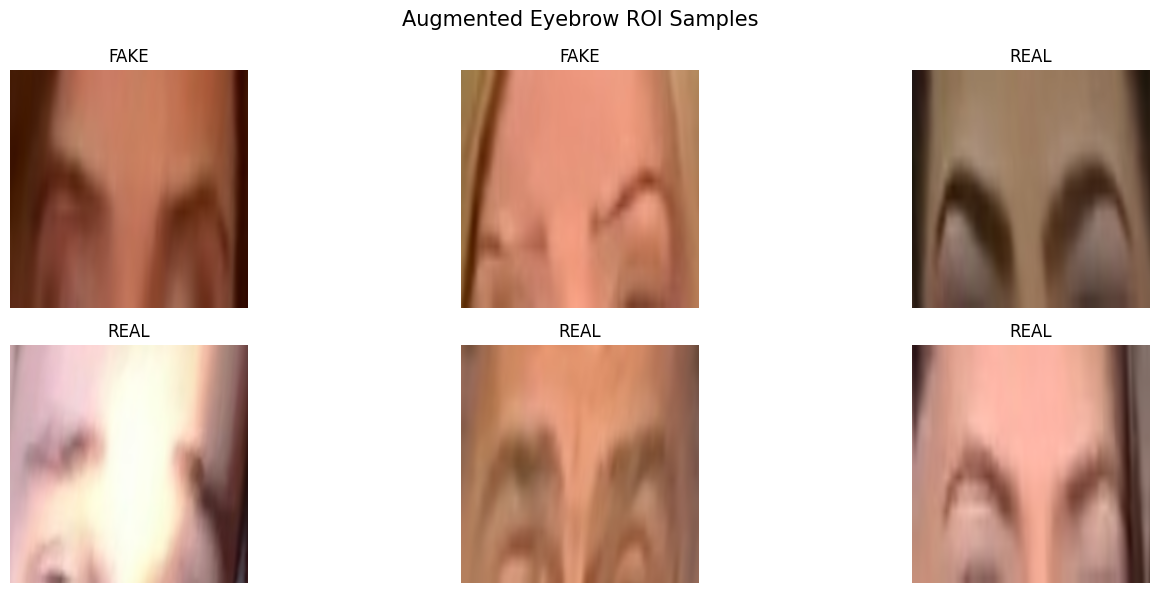


✓ augmentation_config.json kaydedildi.

✓ CELL 5 BAŞARIYLA TAMAMLANDI
✓ Kaş ROI için konservatif augmentation uygulandı.
✓ Horizontal flip aktif mi?: False
✓ Validation ve Test verisine augmentation uygulanmadı.
✓ Xception preprocess_input uygulandı.
✓ Train / Val / Test model girişine hazır.


In [5]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 5 - Eyebrow-Specific Data Augmentation and Preprocessing
# ==========================================================
#
# Amaç:
#
# 1) Yalnızca TRAIN verisine çok hafif augmentation uygulamak.
# 2) Kaş çevresindeki ince doku / sınır / kıl artefaktlarını
#    agresif dönüşümlerle bozmamak.
# 3) Validation ve Test verisini augmentation olmadan kullanmak.
# 4) Xception preprocess_input uygulamak.
#
# KAŞ ROI İÇİN TERCİH:
#
# - Blur YOK
# - Cutout / erasing YOK
# - Güçlü renk manipülasyonu YOK
# - Horizontal flip varsayılan olarak YOK
#
# Neden flip yok?
# Tek kaş veya sağ/sol taraf bilgisi korunuyorsa flip veri
# semantiğini değiştirebilir. Eğer datasetin iki kaşı birlikte
# içerdiğinden ve flip'in deney tasarımına uygun olduğundan
# eminsen aşağıdaki ENABLE_HORIZONTAL_FLIP değerini True yapabilirsin.
# ==========================================================


print("=" * 75)
print("XCEPTION - EYEBROW AUGMENTATION & PREPROCESSING")
print("=" * 75)


# ==========================================================
# 1. KAŞ-ÖZEL AUGMENTATION AYARLARI
# ==========================================================

ENABLE_HORIZONTAL_FLIP = False

augmentation_layers = []

if ENABLE_HORIZONTAL_FLIP:
    augmentation_layers.append(
        layers.RandomFlip(
            mode="horizontal",
            seed=SEED
        )
    )

# Kaş ROI ince ve lokal bir bölge olduğu için
# dönüşümleri ağız notebook'una göre daha konservatif tutuyoruz.
augmentation_layers.extend(
    [
        layers.RandomRotation(
            factor=0.015,
            fill_mode="reflect",
            seed=SEED
        ),

        layers.RandomZoom(
            height_factor=(-0.03, 0.03),
            width_factor=(-0.03, 0.03),
            fill_mode="reflect",
            seed=SEED
        ),

        layers.RandomContrast(
            factor=0.03,
            seed=SEED
        )
    ]
)


data_augmentation = keras.Sequential(
    augmentation_layers,
    name="eyebrow_data_augmentation"
)


# ==========================================================
# 2. TRAIN: AUGMENTATION + XCEPTION PREPROCESSING
# ==========================================================

def prepare_train_batch(images, labels):
    """
    Kaş ROI train batch'ini Xception eğitimine hazırlar.

    Sıra:
    1) Çok hafif kaş-özel augmentation
    2) Xception preprocess_input
    """

    images = data_augmentation(
        images,
        training=True
    )

    images = preprocess_input(
        images
    )

    return images, labels


# ==========================================================
# 3. VALIDATION / TEST: SADECE PREPROCESSING
# ==========================================================

def prepare_eval_batch(images, labels):
    """
    Validation ve Test için augmentation uygulanmaz.
    Yalnızca Xception preprocess_input kullanılır.
    """

    images = preprocess_input(
        images
    )

    return images, labels


# ==========================================================
# 4. DATASETLERİ MODELE HAZIRLA
# ==========================================================

train_ds_xception = train_ds.map(
    prepare_train_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds_xception = val_ds.map(
    prepare_eval_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds_xception = test_ds.map(
    prepare_eval_batch,
    num_parallel_calls=tf.data.AUTOTUNE
)


train_ds_xception = train_ds_xception.prefetch(
    tf.data.AUTOTUNE
)

val_ds_xception = val_ds_xception.prefetch(
    tf.data.AUTOTUNE
)

test_ds_xception = test_ds_xception.prefetch(
    tf.data.AUTOTUNE
)


# ==========================================================
# 5. BİR TRAIN BATCH KONTROLÜ
# ==========================================================

aug_images, aug_labels = next(
    iter(train_ds_xception)
)

print("\n" + "=" * 75)
print("AUGMENTED EYEBROW TRAIN BATCH KONTROLÜ")
print("=" * 75)

print("Image batch shape :", aug_images.shape)
print("Label batch shape :", aug_labels.shape)
print("Image dtype       :", aug_images.dtype)

print(
    "\nPixel minimum:",
    float(tf.reduce_min(aug_images).numpy())
)

print(
    "Pixel maximum:",
    float(tf.reduce_max(aug_images).numpy())
)


# ==========================================================
# 6. AUGMENTATION GÖRSEL KONTROLÜ
# ==========================================================

display_count = min(
    6,
    int(aug_images.shape[0])
)

plt.figure(
    figsize=(15, 6)
)

for i in range(display_count):
    plt.subplot(
        2,
        3,
        i + 1
    )

    # Xception [-1, 1] -> görüntüleme için [0, 1]
    display_image = (
        aug_images[i] + 1.0
    ) / 2.0

    display_image = tf.clip_by_value(
        display_image,
        0.0,
        1.0
    )

    plt.imshow(
        display_image.numpy()
    )

    label_value = int(
        aug_labels[i].numpy()
    )

    label_name = (
        "FAKE"
        if label_value == 1
        else "REAL"
    )

    plt.title(
        label_name
    )

    plt.axis(
        "off"
    )


plt.suptitle(
    "Augmented Eyebrow ROI Samples",
    fontsize=15
)

plt.tight_layout()
plt.show()


# ==========================================================
# 7. AUGMENTATION CONFIG KAYDI
# ==========================================================

augmentation_config = {
    "region":
        "eyebrow",

    "horizontal_flip_enabled":
        bool(
            ENABLE_HORIZONTAL_FLIP
        ),

    "random_rotation_factor":
        0.015,

    "random_zoom_height":
        [
            -0.03,
            0.03
        ],

    "random_zoom_width":
        [
            -0.03,
            0.03
        ],

    "random_contrast_factor":
        0.03,

    "blur":
        False,

    "random_erasing":
        False,

    "xception_preprocess_input":
        True,

    "train_augmentation":
        True,

    "validation_augmentation":
        False,

    "test_augmentation":
        False,

    "seed":
        int(
            SEED
        )
}


AUGMENTATION_CONFIG_PATH = (
    RESULTS_DIR
    / "augmentation_config.json"
)

with open(
    AUGMENTATION_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        augmentation_config,
        file,
        ensure_ascii=False,
        indent=4
    )


print("\n✓ augmentation_config.json kaydedildi.")


# ==========================================================
# 8. CELL SONUCU
# ==========================================================

print("\n" + "=" * 75)
print("✓ CELL 5 BAŞARIYLA TAMAMLANDI")
print("✓ Kaş ROI için konservatif augmentation uygulandı.")
print(f"✓ Horizontal flip aktif mi?: {ENABLE_HORIZONTAL_FLIP}")
print("✓ Validation ve Test verisine augmentation uygulanmadı.")
print("✓ Xception preprocess_input uygulandı.")
print("✓ Train / Val / Test model girişine hazır.")
print("=" * 75)


In [6]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 6 - Build Xception Model
# ==========================================================

# Bu hücrenin amacı:
#
# 1) ImageNet ağırlıklarıyla Xception backbone'u yüklemek.
# 2) Backbone'u ilk eğitim aşamasında dondurmak.
# 3) Üzerine yeni sınıflandırıcı katmanları eklemek.
# 4) Binary classification için sigmoid çıkış üretmek.
# 5) Modeli compile etmek.
#
# ÖNEMLİ:
# Bu hücre model mimarisini oluşturur.
# Henüz model.fit() çalıştırılmaz.
# ==========================================================


print("=" * 70)
print("XCEPTION MODEL BUILD")
print("=" * 70)


# ==========================================================
# 1. XCEPTION BACKBONE
# ==========================================================
#
# include_top=False:
# ImageNet'in orijinal 1000 sınıflı classifier kısmını
# kullanmıyoruz.
#
# weights="imagenet":
# Önceden öğrenilmiş ağırlıklardan başlıyoruz.
#
# input_shape:
# Eyebrow ROI görüntülerimiz 224x224 RGB.


xception_base = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    )
)


# ==========================================================
# 2. BACKBONE'U DONDUR
# ==========================================================
#
# İlk eğitim aşamasında Xception convolution katmanlarını
# değiştirmiyoruz.
#
# Yalnızca ekleyeceğimiz classifier katmanları eğitilecek.
#
# Bunun avantajı:
# - Küçük veri setinde overfitting riskini azaltır.
# - Önceden öğrenilmiş genel görsel feature'ları korur.
# - Eğitimi daha stabil başlatır.


xception_base.trainable = False


print(
    "\n✓ Xception backbone yüklendi."
)

print(
    "✓ ImageNet ağırlıkları kullanılıyor."
)

print(
    "✓ Backbone ilk aşama için donduruldu."
)


# ==========================================================
# 3. MODEL INPUT
# ==========================================================

inputs = keras.Input(
    shape=(
        IMG_HEIGHT,
        IMG_WIDTH,
        3
    ),
    name="eyebrow_roi_input"
)


# ==========================================================
# 4. XCEPTION FEATURE EXTRACTION
# ==========================================================
#
# trainable=False olduğu için backbone weights güncellenmez.
#
# training=False:
# BatchNorm katmanlarının inference modunda çalışmasını sağlar.
# Transfer learning'in ilk aşamasında daha güvenli bir seçimdir.


x = xception_base(
    inputs,
    training=False
)


# ==========================================================
# 5. GLOBAL AVERAGE POOLING
# ==========================================================
#
# Xception'ın son convolution feature map'lerini
# tek bir feature vector haline getirir.
#
# Örneğin:
#
# H x W x C
#
#          ↓
#
#        C boyutlu
#       feature vector


x = layers.GlobalAveragePooling2D(
    name="global_average_pooling"
)(
    x
)


# ==========================================================
# 6. DROPOUT
# ==========================================================
#
# Küçük veri setinde overfitting'i azaltmak için
# Dropout kullanıyoruz.
#
# 0.30 = eğitim sırasında feature'ların %30'u rastgele
# geçici olarak kapatılır.


x = layers.Dropout(
    rate=0.30,
    name="dropout"
)(
    x
)


# ==========================================================
# 7. ARA DENSE KATMAN
# ==========================================================
#
# Xception'dan gelen deep feature vector ile
# final sınıflandırıcı arasında küçük bir öğrenilebilir
# representation oluşturuyoruz.


x = layers.Dense(
    units=256,
    activation="relu",
    name="dense_256"
)(
    x
)


# ==========================================================
# 8. İKİNCİ DROPOUT
# ==========================================================

x = layers.Dropout(
    rate=0.20,
    name="dropout_2"
)(
    x
)


# ==========================================================
# 9. FINAL OUTPUT
# ==========================================================
#
# Binary classification:
#
# REAL = 0
# FAKE = 1
#
# Sigmoid çıkış:
#
# 0'a yakın -> REAL
# 1'e yakın -> FAKE


outputs = layers.Dense(
    units=1,
    activation="sigmoid",
    name="fake_probability"
)(
    x
)


# ==========================================================
# 10. MODEL OLUŞTUR
# ==========================================================

model = keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="Eyebrow_Xception_Deepfake_Detector"
)


# ==========================================================
# 11. OPTIMIZER
# ==========================================================
#
# İlk transfer-learning aşamasında:
#
# Adam optimizer
# learning_rate = 1e-4
#
# oldukça güvenli bir başlangıçtır.


INITIAL_LEARNING_RATE = 1e-4


optimizer = keras.optimizers.Adam(
    learning_rate=INITIAL_LEARNING_RATE
)


# ==========================================================
# 12. LOSS FUNCTION
# ==========================================================
#
# İki sınıflı problem:
#
# REAL / FAKE
#
# Dolayısıyla Binary Cross Entropy kullanıyoruz.


loss_function = keras.losses.BinaryCrossentropy()


# ==========================================================
# 13. TRAINING METRICS
# ==========================================================
#
# Eğitim sırasında:
#
# accuracy
# precision
# recall
# AUC
#
# takip edilecek.
#
# F1 score'u daha sonra test tahminlerinden sklearn ile
# ayrıca hesaplayacağız.


training_metrics = [

    keras.metrics.BinaryAccuracy(
        name="accuracy"
    ),

    keras.metrics.Precision(
        name="precision"
    ),

    keras.metrics.Recall(
        name="recall"
    ),

    keras.metrics.AUC(
        name="auc"
    )
]


# ==========================================================
# 14. MODEL COMPILE
# ==========================================================

model.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=training_metrics
)


# ==========================================================
# 15. MODEL SUMMARY
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "MODEL SUMMARY"
)

print(
    "=" * 70
)


model.summary()


# ==========================================================
# 16. PARAMETRE SAYILARI
# ==========================================================

total_params = model.count_params()


trainable_params = sum(
    int(
        np.prod(
            variable.shape
        )
    )
    for variable in model.trainable_weights
)


non_trainable_params = (
    total_params
    - trainable_params
)


print(
    "\n"
    + "=" * 70
)

print(
    "PARAMETER SUMMARY"
)

print(
    "=" * 70
)


print(
    f"Total parameters      : "
    f"{total_params:,}"
)


print(
    f"Trainable parameters  : "
    f"{trainable_params:,}"
)


print(
    f"Frozen parameters     : "
    f"{non_trainable_params:,}"
)


# ==========================================================
# 17. BACKBONE DURUMU
# ==========================================================

print(
    "\nXception backbone trainable:",
    xception_base.trainable
)


# ==========================================================
# 18. MODEL CONFIG KAYDI
# ==========================================================
#
# Deney tekrarlanabilirliği için kullanılan model ayarlarını
# JSON olarak kaydediyoruz.


model_config = {

    "model_name":
        "Xception",

    "experiment_name":
        "Eyebrow_Xception_Deepfake_Detector",

    "region":
        "eyebrow",

    "weights":
        "imagenet",

    "include_top":
        False,

    "input_size": [
        int(
            IMG_HEIGHT
        ),
        int(
            IMG_WIDTH
        ),
        3
    ],

    "backbone_trainable_initially":
        False,

    "global_average_pooling":
        True,

    "dropout_1":
        0.30,

    "dense_units":
        256,

    "dense_activation":
        "relu",

    "dropout_2":
        0.20,

    "output_units":
        1,

    "output_activation":
        "sigmoid",

    "optimizer":
        "Adam",

    "initial_learning_rate":
        float(
            INITIAL_LEARNING_RATE
        ),

    "loss":
        "BinaryCrossentropy",

    "class_mapping": {
        "real": 0,
        "fake": 1
    },

    "metrics": [
        "accuracy",
        "precision",
        "recall",
        "auc"
    ]
}


MODEL_CONFIG_PATH = (
    ARTIFACTS_DIR
    / "xception_model_config.json"
)


with open(
    MODEL_CONFIG_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        model_config,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ xception_model_config.json kaydedildi."
)


# ==========================================================
# 19. CELL SONUCU
# ==========================================================

print(
    "\n"
    + "=" * 70
)

print(
    "✓ CELL 6 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ ImageNet pretrained Xception hazır."
)

print(
    "✓ Xception backbone donduruldu."
)

print(
    "✓ Deep feature extraction katmanları hazır."
)

print(
    "✓ Global Average Pooling eklendi."
)

print(
    "✓ Dense classifier eklendi."
)

print(
    "✓ REAL = 0 / FAKE = 1."
)

print(
    "✓ Model compile edildi."
)

print(
    "✓ Henüz eğitim başlamadı."
)

print("=" * 70)

XCEPTION MODEL BUILD
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

✓ Xception backbone yüklendi.
✓ ImageNet ağırlıkları kullanılıyor.
✓ Backbone ilk aşama için donduruldu.

MODEL SUMMARY


Model: "Eyebrow_Xception_Deepfake_Detector"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eyebrow_roi_input (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 7, 7, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fake_probability (Dense)        │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,386,281 (81.58 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 20,861,480 (79.58 MB)


PARAMETER SUMMARY
Total parameters      : 21,386,281
Trainable parameters  : 524,801
Frozen parameters     : 20,861,480

Xception backbone trainable: False

✓ xception_model_config.json kaydedildi.

✓ CELL 6 BAŞARIYLA TAMAMLANDI
✓ ImageNet pretrained Xception hazır.
✓ Xception backbone donduruldu.
✓ Deep feature extraction katmanları hazır.
✓ Global Average Pooling eklendi.
✓ Dense classifier eklendi.
✓ REAL = 0 / FAKE = 1.
✓ Model compile edildi.
✓ Henüz eğitim başlamadı.


In [7]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 7 - Initial Training with Frozen Xception Backbone
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Xception backbone dondurulmuş halde ilk eğitimi başlatmak.
# 2) Yalnızca üstteki classifier katmanlarını eğitmek.
# 3) Validation performansını takip etmek.
# 4) En iyi modeli otomatik kaydetmek.
# 5) Overfitting / gereksiz uzun eğitim riskini azaltmak.
#
# Bu aşama bittikten sonra fine-tuning'e geçeceğiz.
# ==========================================================


print("=" * 70)
print("XCEPTION - INITIAL FROZEN BACKBONE TRAINING")
print("=" * 70)


# ==========================================================
# 1. EPOCH SAYISI
# ==========================================================
#
# İlk aşamada 15 epoch yeterli bir başlangıçtır.
#
# EarlyStopping nedeniyle model gerekirse daha erken duracaktır.

INITIAL_EPOCHS = 15


# ==========================================================
# 2. MODEL CHECKPOINT YOLU
# ==========================================================
#
# Validation AUC değeri en iyi olduğunda model kaydedilecek.
#
# .keras formatı yeni Keras formatıdır.


BEST_FROZEN_MODEL_PATH = (
    MODEL_DIR
    / "best_xception_frozen.keras"
)


# ==========================================================
# 3. TRAINING LOG CSV
# ==========================================================
#
# Her epoch sonucunu ayrıca CSV olarak saklıyoruz.
#
# Böylece daha sonra raporda:
#
# - loss
# - accuracy
# - precision
# - recall
# - auc
#
# değerlerini inceleyebiliriz.


FROZEN_TRAINING_LOG_PATH = (
    LOGS_DIR
    / "frozen_training_log.csv"
)


# ==========================================================
# 4. CALLBACK - MODEL CHECKPOINT
# ==========================================================
#
# En yüksek validation AUC değerine sahip modeli kaydeder.
#
# Neden val_auc?
#
# Accuracy tek başına yeterli değildir.
# Deepfake detection binary classification probleminde
# AUC modelin sınıfları ayırma gücü açısından önemli bir metriktir.


checkpoint_callback = keras.callbacks.ModelCheckpoint(

    filepath=str(
        BEST_FROZEN_MODEL_PATH
    ),

    monitor="val_auc",

    mode="max",

    save_best_only=True,

    save_weights_only=False,

    verbose=1
)


# ==========================================================
# 5. CALLBACK - EARLY STOPPING
# ==========================================================
#
# Validation AUC 4 epoch boyunca iyileşmezse eğitim durur.
#
# restore_best_weights=True:
# eğitim sonunda en iyi epoch ağırlıklarına geri döner.


early_stopping_callback = keras.callbacks.EarlyStopping(

    monitor="val_auc",

    mode="max",

    patience=4,

    restore_best_weights=True,

    verbose=1
)


# ==========================================================
# 6. CALLBACK - REDUCE LEARNING RATE
# ==========================================================
#
# Validation loss 2 epoch boyunca iyileşmezse
# learning rate yarıya düşürülür.


reduce_lr_callback = keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    mode="min",

    factor=0.5,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


# ==========================================================
# 7. CALLBACK - CSV LOGGER
# ==========================================================

csv_logger_callback = keras.callbacks.CSVLogger(

    filename=str(
        FROZEN_TRAINING_LOG_PATH
    ),

    separator=",",

    append=False
)


# ==========================================================
# 8. CALLBACK LİSTESİ
# ==========================================================

callbacks_initial = [

    checkpoint_callback,

    early_stopping_callback,

    reduce_lr_callback,

    csv_logger_callback
]


# ==========================================================
# 9. TRAINING ÖNCESİ MODEL DURUMU
# ==========================================================

print("\nTraining configuration:")

print(
    f"Initial epochs        : "
    f"{INITIAL_EPOCHS}"
)

print(
    f"Initial learning rate : "
    f"{INITIAL_LEARNING_RATE}"
)

print(
    f"Batch size            : "
    f"{BATCH_SIZE}"
)

print(
    f"Train samples         : "
    f"{TRAIN_TOTAL}"
)

print(
    f"Validation samples    : "
    f"{VAL_TOTAL}"
)

print(
    f"Xception trainable    : "
    f"{xception_base.trainable}"
)

print(
    f"Best model path       : "
    f"{BEST_FROZEN_MODEL_PATH}"
)


# ==========================================================
# 10. EĞİTİM BAŞLANGIÇ ZAMANI
# ==========================================================

initial_training_start = time.perf_counter()


# ==========================================================
# 11. MODEL TRAINING
# ==========================================================
#
# İlk gerçek model.fit() burada çalışıyor.
#
# train_ds_xception:
# augmentation + Xception preprocessing uygulanmış train set.
#
# val_ds_xception:
# augmentation yok, yalnızca preprocessing var.


history_frozen = model.fit(

    train_ds_xception,

    validation_data=val_ds_xception,

    epochs=INITIAL_EPOCHS,

    callbacks=callbacks_initial,

    verbose=1
)


# ==========================================================
# 12. EĞİTİM SÜRESİ
# ==========================================================

initial_training_seconds = (
    time.perf_counter()
    - initial_training_start
)


initial_training_minutes = (
    initial_training_seconds
    / 60
)


print("\n" + "=" * 70)

print(
    f"Frozen training süresi: "
    f"{initial_training_minutes:.2f} dakika"
)

print("=" * 70)


# ==========================================================
# 13. GERÇEKLEŞEN EPOCH SAYISI
# ==========================================================

completed_initial_epochs = len(
    history_frozen.history[
        "loss"
    ]
)


print(
    f"\nGerçekleşen epoch sayısı: "
    f"{completed_initial_epochs}"
)


# ==========================================================
# 14. EN İYİ VALIDATION AUC
# ==========================================================

best_val_auc = max(
    history_frozen.history[
        "val_auc"
    ]
)


best_val_auc_epoch = (
    int(
        np.argmax(
            history_frozen.history[
                "val_auc"
            ]
        )
    )
    + 1
)


print(
    f"En iyi validation AUC: "
    f"{best_val_auc:.4f}"
)

print(
    f"En iyi epoch         : "
    f"{best_val_auc_epoch}"
)


# ==========================================================
# 15. EN İYİ VALIDATION ACCURACY
# ==========================================================

best_val_accuracy = max(
    history_frozen.history[
        "val_accuracy"
    ]
)


print(
    f"En iyi validation accuracy: "
    f"{best_val_accuracy:.4f}"
)


# ==========================================================
# 16. TRAINING HISTORY'Yİ DATAFRAME'E ÇEVİR
# ==========================================================

history_frozen_df = pd.DataFrame(
    history_frozen.history
)


history_frozen_df.insert(
    0,
    "epoch",
    range(
        1,
        len(history_frozen_df) + 1
    )
)


# ==========================================================
# 17. HISTORY CSV KAYDET
# ==========================================================

FROZEN_HISTORY_PATH = (
    RESULTS_DIR
    / "frozen_training_history.csv"
)


history_frozen_df.to_csv(

    FROZEN_HISTORY_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ frozen_training_history.csv kaydedildi."
)


# ==========================================================
# 18. EĞİTİM ÖZET JSON
# ==========================================================

frozen_training_summary = {

    "training_stage":
        "frozen_backbone",

    "requested_epochs":
        int(
            INITIAL_EPOCHS
        ),

    "completed_epochs":
        int(
            completed_initial_epochs
        ),

    "batch_size":
        int(
            BATCH_SIZE
        ),

    "initial_learning_rate":
        float(
            INITIAL_LEARNING_RATE
        ),

    "train_samples":
        int(
            TRAIN_TOTAL
        ),

    "validation_samples":
        int(
            VAL_TOTAL
        ),

    "best_validation_auc":
        float(
            best_val_auc
        ),

    "best_validation_auc_epoch":
        int(
            best_val_auc_epoch
        ),

    "best_validation_accuracy":
        float(
            best_val_accuracy
        ),

    "training_seconds":
        float(
            initial_training_seconds
        ),

    "training_minutes":
        float(
            initial_training_minutes
        ),

    "best_model_path":
        str(
            BEST_FROZEN_MODEL_PATH
        )
}


FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


with open(
    FROZEN_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        frozen_training_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ frozen_training_summary.json kaydedildi."
)


# ==========================================================
# 19. MODEL DOSYASI KONTROLÜ
# ==========================================================

print(
    "\nBest model mevcut mu? :",
    BEST_FROZEN_MODEL_PATH.exists()
)


# ==========================================================
# 20. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 7 TAMAMLANDI"
)

print(
    "✓ Frozen Xception eğitimi tamamlandı."
)

print(
    "✓ En iyi validation AUC modeli kaydedildi."
)

print(
    "✓ Training log kaydedildi."
)

print(
    "✓ EarlyStopping aktifti."
)

print(
    "✓ ReduceLROnPlateau aktifti."
)

print(
    "✓ Sonraki aşama: Fine-Tuning."
)

print("=" * 70)

XCEPTION - INITIAL FROZEN BACKBONE TRAINING

Training configuration:
Initial epochs        : 15
Initial learning rate : 0.0001
Batch size            : 16
Train samples         : 1562
Validation samples    : 204
Xception trainable    : False
Best model path       : /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/checkpoints/best_xception_frozen.keras
Epoch 1/15
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.5189 - auc: 0.5250 - loss: 0.7117 - precision: 0.5205 - recall: 0.4893
Epoch 1: val_auc improved from None to 0.60926, saving model to /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/checkpoints/best_xception_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/checkpoints/best_xception_frozen.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 73s 

In [8]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 8 - Xception Fine-Tuning
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Cell 7'de eğitilen en iyi frozen modeli yüklemek.
# 2) Xception backbone'un tamamını artık erişilebilir yapmak.
# 3) Ancak yalnızca SON belirli sayıdaki katmanı eğitime açmak.
# 4) BatchNormalization katmanlarını frozen bırakmak.
# 5) Learning rate'i ciddi şekilde azaltmak.
# 6) Fine-tuning ile kaş bölgesine daha özel deep feature'lar
#    öğrenilmesini sağlamak.
#
# ----------------------------------------------------------
# NEDEN FINE-TUNING?
#
# İlk aşamada Xception:
#
# ImageNet'ten öğrendiği genel görsel özellikleri kullandı.
#
# Fine-tuning aşamasında ise son convolution katmanlarının
# kaş deepfake problemine daha fazla adapte olması amaçlanır.
#
# Örneğin model;
#
# - kaş kılı-cilt sınırı geçişleri
# - lokal texture farklılıkları
# - kaş çevresindeki ince kenar ve blending yapıları
# - blending artefaktları
# - doğal olmayan kenar yapıları
#
# gibi ayırt edici örüntülere daha duyarlı hale gelebilir.
#
# NOT:
# Bu özelliklerin gerçekten öğrenildiğini yalnızca model
# performansından kesin söyleyemeyiz. Daha sonra Grad-CAM gibi
# açıklanabilirlik yöntemleriyle inceleyebiliriz.
# ==========================================================


print("=" * 70)
print("XCEPTION - FINE-TUNING")
print("=" * 70)


# ==========================================================
# 1. CELL 7 MODELİNİ KONTROL ET
# ==========================================================

if not BEST_FROZEN_MODEL_PATH.exists():

    raise FileNotFoundError(
        "Cell 7'de kaydedilmesi gereken "
        "best_xception_frozen.keras bulunamadı."
    )


print(
    "\n✓ Frozen aşamadaki en iyi model bulundu."
)


# ==========================================================
# 2. EN İYİ FROZEN MODELİ YÜKLE
# ==========================================================
#
# Cell 7'nin son epoch'unu değil,
# validation AUC açısından EN İYİ modeli kullanıyoruz.


model = keras.models.load_model(
    BEST_FROZEN_MODEL_PATH
)


print(
    "✓ En iyi frozen model yüklendi."
)


# ==========================================================
# 3. MODEL İÇERİSİNDEKİ XCEPTION BACKBONE'U BUL
# ==========================================================

xception_base = model.get_layer(
    "xception"
)


print(
    "\nXception katman sayısı:",
    len(xception_base.layers)
)


# ==========================================================
# 4. BACKBONE'U TRAINABLE YAP
# ==========================================================
#
# Önce genel olarak trainable=True diyoruz.
#
# Bir sonraki adımda katmanların büyük bölümünü tekrar
# donduracağız.


xception_base.trainable = True


# ==========================================================
# 5. KAÇ SON KATMANI AÇACAĞIZ?
# ==========================================================
#
# İlk fine-tuning denemesinde son 30 katmanı açıyoruz.
#
# Bu değer kontrollü bir başlangıçtır.
#
# Çok fazla katmanı bir anda açmak:
# - overfitting
# - pretrained özelliklerin bozulması
# - training instability
#
# oluşturabilir.


UNFREEZE_LAST_N = 30


# ==========================================================
# 6. ÖNCE TÜM BACKBONE KATMANLARINI DONDUR
# ==========================================================

for layer in xception_base.layers:

    layer.trainable = False


# ==========================================================
# 7. SON N KATMANI AÇ
# ==========================================================

for layer in xception_base.layers[
    -UNFREEZE_LAST_N:
]:

    # ------------------------------------------------------
    # BatchNormalization özel durumu
    # ------------------------------------------------------
    #
    # Küçük dataset + küçük batch size durumunda
    # BatchNorm istatistiklerini yeniden öğrenmek
    # kararsızlık oluşturabilir.
    #
    # Bu nedenle BatchNormalization katmanlarını
    # frozen bırakıyoruz.

    if isinstance(
        layer,
        layers.BatchNormalization
    ):

        layer.trainable = False

    else:

        layer.trainable = True


# ==========================================================
# 8. TRAINABLE BACKBONE KATMANLARINI SAY
# ==========================================================

trainable_backbone_layers = [

    layer.name

    for layer in xception_base.layers

    if layer.trainable
]


print(
    f"\nFine-tuning için açılan backbone katman sayısı: "
    f"{len(trainable_backbone_layers)}"
)


print(
    "\nTrainable Xception katmanlarından son birkaç örnek:"
)


for layer_name in trainable_backbone_layers[
    -10:
]:

    print(
        " -",
        layer_name
    )


# ==========================================================
# 9. FINE-TUNING LEARNING RATE
# ==========================================================
#
# Fine-tuning sırasında pretrained ağırlıkları
# hızlı biçimde bozmak istemiyoruz.
#
# Bu nedenle ilk aşamadaki 1e-4 yerine:
#
# 1e-5
#
# kullanıyoruz.


FINE_TUNE_LEARNING_RATE = 1e-5


fine_tune_optimizer = keras.optimizers.Adam(
    learning_rate=FINE_TUNE_LEARNING_RATE
)


# ==========================================================
# 10. MODELİ YENİDEN COMPILE ET
# ==========================================================
#
# trainable katmanlar değiştirildikten sonra modelin
# MUTLAKA yeniden compile edilmesi gerekir.


model.compile(

    optimizer=fine_tune_optimizer,

    loss=keras.losses.BinaryCrossentropy(),

    metrics=[

        keras.metrics.BinaryAccuracy(
            name="accuracy"
        ),

        keras.metrics.Precision(
            name="precision"
        ),

        keras.metrics.Recall(
            name="recall"
        ),

        keras.metrics.AUC(
            name="auc"
        )
    ]
)


print(
    "\n✓ Model fine-tuning için yeniden compile edildi."
)


# ==========================================================
# 11. PARAMETRE SAYILARI
# ==========================================================

total_params_ft = model.count_params()


trainable_params_ft = sum(

    int(
        np.prod(
            variable.shape
        )
    )

    for variable in model.trainable_weights
)


frozen_params_ft = (
    total_params_ft
    - trainable_params_ft
)


print("\n" + "=" * 70)
print("FINE-TUNING PARAMETER SUMMARY")
print("=" * 70)


print(
    f"Total parameters     : "
    f"{total_params_ft:,}"
)


print(
    f"Trainable parameters : "
    f"{trainable_params_ft:,}"
)


print(
    f"Frozen parameters    : "
    f"{frozen_params_ft:,}"
)


# ==========================================================
# 12. FINE-TUNING EPOCH SAYISI
# ==========================================================

FINE_TUNE_EPOCHS = 10


# ==========================================================
# 13. EN İYİ FINE-TUNED MODEL YOLU
# ==========================================================

BEST_FINE_TUNED_MODEL_PATH = (
    MODEL_DIR
    / "best_xception_finetuned.keras"
)


# ==========================================================
# 14. FINE-TUNING CSV LOG
# ==========================================================

FINE_TUNE_LOG_PATH = (
    LOGS_DIR
    / "finetune_training_log.csv"
)


# ==========================================================
# 15. MODEL CHECKPOINT
# ==========================================================

finetune_checkpoint = (
    keras.callbacks.ModelCheckpoint(

        filepath=str(
            BEST_FINE_TUNED_MODEL_PATH
        ),

        monitor="val_auc",

        mode="max",

        save_best_only=True,

        save_weights_only=False,

        verbose=1
    )
)


# ==========================================================
# 16. EARLY STOPPING
# ==========================================================

finetune_early_stopping = (
    keras.callbacks.EarlyStopping(

        monitor="val_auc",

        mode="max",

        patience=4,

        restore_best_weights=True,

        verbose=1
    )
)


# ==========================================================
# 17. REDUCE LEARNING RATE
# ==========================================================

finetune_reduce_lr = (
    keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.5,

        patience=2,

        min_lr=1e-7,

        verbose=1
    )
)


# ==========================================================
# 18. CSV LOGGER
# ==========================================================

finetune_csv_logger = (
    keras.callbacks.CSVLogger(

        filename=str(
            FINE_TUNE_LOG_PATH
        ),

        separator=",",

        append=False
    )
)


# ==========================================================
# 19. CALLBACK LİSTESİ
# ==========================================================

callbacks_finetune = [

    finetune_checkpoint,

    finetune_early_stopping,

    finetune_reduce_lr,

    finetune_csv_logger
]


# ==========================================================
# 20. FINE-TUNING KONFİGÜRASYONU
# ==========================================================

print("\n" + "=" * 70)
print("FINE-TUNING CONFIGURATION")
print("=" * 70)


print(
    f"Unfreeze last N      : "
    f"{UNFREEZE_LAST_N}"
)


print(
    f"Trainable Xception   : "
    f"{len(trainable_backbone_layers)} katman"
)


print(
    f"Learning rate        : "
    f"{FINE_TUNE_LEARNING_RATE}"
)


print(
    f"Maximum epochs       : "
    f"{FINE_TUNE_EPOCHS}"
)


print(
    f"Train samples        : "
    f"{TRAIN_TOTAL}"
)


print(
    f"Validation samples   : "
    f"{VAL_TOTAL}"
)


# ==========================================================
# 21. FINE-TUNING BAŞLANGIÇ ZAMANI
# ==========================================================

finetune_start_time = (
    time.perf_counter()
)


# ==========================================================
# 22. FINE-TUNING BAŞLAT
# ==========================================================

history_finetune = model.fit(

    train_ds_xception,

    validation_data=(
        val_ds_xception
    ),

    epochs=(
        FINE_TUNE_EPOCHS
    ),

    callbacks=(
        callbacks_finetune
    ),

    verbose=1
)


# ==========================================================
# 23. FINE-TUNING SÜRESİ
# ==========================================================

finetune_seconds = (

    time.perf_counter()
    - finetune_start_time
)


finetune_minutes = (
    finetune_seconds
    / 60
)


print("\n" + "=" * 70)

print(
    f"Fine-tuning süresi: "
    f"{finetune_minutes:.2f} dakika"
)

print("=" * 70)


# ==========================================================
# 24. GERÇEKLEŞEN EPOCH SAYISI
# ==========================================================

completed_finetune_epochs = len(

    history_finetune.history[
        "loss"
    ]
)


# ==========================================================
# 25. EN İYİ VALIDATION AUC
# ==========================================================

best_finetune_val_auc = max(

    history_finetune.history[
        "val_auc"
    ]
)


best_finetune_epoch = (

    int(
        np.argmax(
            history_finetune.history[
                "val_auc"
            ]
        )
    )

    + 1
)


# ==========================================================
# 26. EN İYİ VALIDATION ACCURACY
# ==========================================================

best_finetune_val_accuracy = max(

    history_finetune.history[
        "val_accuracy"
    ]
)


print(
    f"\nGerçekleşen fine-tuning epoch: "
    f"{completed_finetune_epochs}"
)


print(
    f"En iyi fine-tuning val AUC    : "
    f"{best_finetune_val_auc:.4f}"
)


print(
    f"En iyi fine-tuning epoch      : "
    f"{best_finetune_epoch}"
)


print(
    f"En iyi fine-tuning val acc    : "
    f"{best_finetune_val_accuracy:.4f}"
)


# ==========================================================
# 27. HISTORY DATAFRAME
# ==========================================================

history_finetune_df = pd.DataFrame(
    history_finetune.history
)


history_finetune_df.insert(

    0,

    "epoch",

    range(
        1,
        len(history_finetune_df) + 1
    )
)


# ==========================================================
# 28. HISTORY CSV
# ==========================================================

FINE_TUNE_HISTORY_PATH = (
    RESULTS_DIR
    / "finetune_training_history.csv"
)


history_finetune_df.to_csv(

    FINE_TUNE_HISTORY_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ finetune_training_history.csv kaydedildi."
)


# ==========================================================
# 29. FINE-TUNING SUMMARY JSON
# ==========================================================

finetune_summary = {

    "training_stage":
        "fine_tuning",

    "unfreeze_last_n":
        int(
            UNFREEZE_LAST_N
        ),

    "trainable_xception_layers":
        int(
            len(
                trainable_backbone_layers
            )
        ),

    "requested_epochs":
        int(
            FINE_TUNE_EPOCHS
        ),

    "completed_epochs":
        int(
            completed_finetune_epochs
        ),

    "learning_rate":
        float(
            FINE_TUNE_LEARNING_RATE
        ),

    "best_validation_auc":
        float(
            best_finetune_val_auc
        ),

    "best_validation_auc_epoch":
        int(
            best_finetune_epoch
        ),

    "best_validation_accuracy":
        float(
            best_finetune_val_accuracy
        ),

    "training_seconds":
        float(
            finetune_seconds
        ),

    "training_minutes":
        float(
            finetune_minutes
        ),

    "best_model_path":
        str(
            BEST_FINE_TUNED_MODEL_PATH
        )
}


FINE_TUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


with open(
    FINE_TUNE_SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        finetune_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ finetune_training_summary.json kaydedildi."
)


# ==========================================================
# 30. MODEL DOSYASI KONTROLÜ
# ==========================================================

print(
    "\nFine-tuned model mevcut mu? :",
    BEST_FINE_TUNED_MODEL_PATH.exists()
)


# ==========================================================
# 31. CELL SONUCU
# ==========================================================

print("\n" + "=" * 70)

print(
    "✓ CELL 8 TAMAMLANDI"
)

print(
    "✓ Xception fine-tuning tamamlandı."
)

print(
    "✓ Son katmanların bir kısmı ağız verisine adapte edildi."
)

print(
    "✓ BatchNormalization katmanları frozen tutuldu."
)

print(
    "✓ Düşük learning rate kullanıldı."
)

print(
    "✓ En iyi fine-tuned model kaydedildi."
)

print(
    "✓ Sonraki aşama: TEST SETİ DEĞERLENDİRMESİ."
)

print("=" * 70)

XCEPTION - FINE-TUNING

✓ Frozen aşamadaki en iyi model bulundu.
✓ En iyi frozen model yüklendi.

Xception katman sayısı: 132

Fine-tuning için açılan backbone katman sayısı: 21

Trainable Xception katmanlarından son birkaç örnek:
 - block13_sepconv1
 - block13_sepconv2_act
 - block13_sepconv2
 - conv2d_3
 - block13_pool
 - add_11
 - block14_sepconv1
 - block14_sepconv1_act
 - block14_sepconv2
 - block14_sepconv2_act

✓ Model fine-tuning için yeniden compile edildi.

FINE-TUNING PARAMETER SUMMARY
Total parameters     : 21,386,281
Trainable parameters : 9,446,609
Frozen parameters    : 11,939,672

FINE-TUNING CONFIGURATION
Unfreeze last N      : 30
Trainable Xception   : 21 katman
Learning rate        : 1e-05
Maximum epochs       : 10
Train samples        : 1562
Validation samples   : 204
Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.5870 - auc: 0.6374 - loss: 0.6624 - precision: 0.6042 - recall: 0.6199
Epoch 1: val_auc improved from None to 0.62977, saving model to 

In [9]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 9 - Best Model Selection and Test Set Prediction
# ==========================================================

# Bu hücrenin amacı:
#
# 1) Cell 7'deki Frozen Xception sonucunu okumak.
# 2) Cell 8'deki Fine-Tuned Xception sonucunu okumak.
# 3) Validation AUC değerlerine göre EN İYİ modeli seçmek.
# 4) Seçilen modeli yüklemek.
# 5) Daha önce model seçiminde kullanılmamış TEST SETİ
#    üzerinde tahmin üretmek.
# 6) Her test görüntüsü için P(fake) skorunu kaydetmek.
#
# ----------------------------------------------------------
# ÖNEMLİ BİLİMSEL NOKTA
# ----------------------------------------------------------
#
# Test setine bakarak model seçmiyoruz.
#
# Model seçimi:
#       VALIDATION AUC
#
# üzerinden yapılır.
#
# Test seti yalnızca seçilen nihai modelin
# tarafsız performansını ölçmek için kullanılır.
#
# REAL = 0
# FAKE = 1
#
# Sigmoid çıktısı:
#       P(fake)
#
# olarak yorumlanacaktır.
# ==========================================================


print("=" * 75)
print("XCEPTION - BEST MODEL SELECTION & TEST PREDICTION")
print("=" * 75)


# ==========================================================
# 1. CELL 7 VE CELL 8 ÖZET DOSYALARI
# ==========================================================

FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


FINE_TUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


# ==========================================================
# 2. DOSYALARIN VARLIĞINI KONTROL ET
# ==========================================================

if not FROZEN_SUMMARY_PATH.exists():

    raise FileNotFoundError(
        "Frozen training summary bulunamadı. "
        "Cell 7'nin başarıyla tamamlandığını kontrol et."
    )


if not FINE_TUNE_SUMMARY_PATH.exists():

    raise FileNotFoundError(
        "Fine-tuning summary bulunamadı. "
        "Cell 8'in başarıyla tamamlandığını kontrol et."
    )


print("\n✓ Cell 7 ve Cell 8 sonuç dosyaları bulundu.")


# ==========================================================
# 3. FROZEN SONUCU OKU
# ==========================================================

with open(
    FROZEN_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as file:

    frozen_summary = json.load(
        file
    )


# ==========================================================
# 4. FINE-TUNING SONUCU OKU
# ==========================================================

with open(
    FINE_TUNE_SUMMARY_PATH,
    "r",
    encoding="utf-8"
) as file:

    finetune_summary = json.load(
        file
    )


# ==========================================================
# 5. VALIDATION AUC DEĞERLERİNİ AL
# ==========================================================

frozen_val_auc = float(
    frozen_summary[
        "best_validation_auc"
    ]
)


finetune_val_auc = float(
    finetune_summary[
        "best_validation_auc"
    ]
)


print("\n" + "=" * 75)
print("VALIDATION MODEL COMPARISON")
print("=" * 75)


print(
    f"Frozen Xception best val AUC : "
    f"{frozen_val_auc:.4f}"
)


print(
    f"Fine-Tuned best val AUC      : "
    f"{finetune_val_auc:.4f}"
)


# ==========================================================
# 6. EN İYİ MODELİ SEÇ
# ==========================================================
#
# Test setine bakmıyoruz.
#
# Yalnızca VALIDATION AUC üzerinden seçim yapıyoruz.


if finetune_val_auc > frozen_val_auc:

    SELECTED_MODEL_STAGE = (
        "fine_tuned"
    )

    SELECTED_MODEL_PATH = (
        BEST_FINE_TUNED_MODEL_PATH
    )

    SELECTED_VAL_AUC = (
        finetune_val_auc
    )


else:

    SELECTED_MODEL_STAGE = (
        "frozen"
    )

    SELECTED_MODEL_PATH = (
        BEST_FROZEN_MODEL_PATH
    )

    SELECTED_VAL_AUC = (
        frozen_val_auc
    )


print("\n" + "=" * 75)
print("SELECTED FINAL MODEL")
print("=" * 75)


print(
    "Selected stage :",
    SELECTED_MODEL_STAGE
)


print(
    "Selected val AUC:",
    f"{SELECTED_VAL_AUC:.4f}"
)


print(
    "Model path:"
)

print(
    SELECTED_MODEL_PATH
)


# ==========================================================
# 7. MODEL DOSYASI GERÇEKTEN VAR MI?
# ==========================================================

if not Path(
    SELECTED_MODEL_PATH
).exists():

    raise FileNotFoundError(
        f"Seçilen model dosyası bulunamadı:\n"
        f"{SELECTED_MODEL_PATH}"
    )


# ==========================================================
# 8. EN İYİ MODELİ YÜKLE
# ==========================================================

best_model = keras.models.load_model(
    SELECTED_MODEL_PATH
)


print(
    "\n✓ Seçilen nihai Xception modeli yüklendi."
)


# ==========================================================
# 9. TEST SETİNİ MODEL.EVALUATE İLE DEĞERLENDİR
# ==========================================================
#
# Burada ilk genel test sonuçlarını alıyoruz.
#
# Ancak Cell 10'da sklearn kullanarak:
#
# Accuracy
# Precision
# Recall
# F1
# ROC-AUC
# Confusion Matrix değerleri
#
# ayrıca ayrıntılı hesaplanacak.


print("\n" + "=" * 75)
print("TEST SET EVALUATION")
print("=" * 75)


test_start_time = (
    time.perf_counter()
)


test_evaluation = best_model.evaluate(

    test_ds_xception,

    verbose=1,

    return_dict=True
)


test_evaluation_seconds = (
    time.perf_counter()
    - test_start_time
)


print("\nKeras Test Results:")


for metric_name, metric_value in (
    test_evaluation.items()
):

    print(
        f"{metric_name:<12}: "
        f"{metric_value:.4f}"
    )


# ==========================================================
# 10. TEST SETİ TAHMİNLERİ
# ==========================================================
#
# Modelin sigmoid çıkışı P(fake)'dir.
#
# Örnek:
#
# 0.08 -> büyük olasılıkla REAL
# 0.92 -> büyük olasılıkla FAKE


print("\n" + "=" * 75)
print("TEST PREDICTIONS")
print("=" * 75)


prediction_start_time = (
    time.perf_counter()
)


test_probabilities = best_model.predict(

    test_ds_xception,

    verbose=1
)


prediction_seconds = (
    time.perf_counter()
    - prediction_start_time
)


# ==========================================================
# 11. SHAPE DÜZELT
# ==========================================================
#
# Model çıktısı:
#
# (302, 1)
#
# olabilir.
#
# Bunu:
#
# (302,)
#
# haline getiriyoruz.


test_probabilities = (
    test_probabilities
    .reshape(-1)
)


print(
    "\nPrediction shape:",
    test_probabilities.shape
)


# ==========================================================
# 12. GERÇEK TEST LABEL'LARINI AL
# ==========================================================
#
# Cell 4'te test setini shuffle etmemiştik.
#
# Dolayısıyla test_labels sırası ile prediction sırası
# aynıdır.


y_true = np.array(
    test_labels,
    dtype=np.int32
)


print(
    "True labels shape:",
    y_true.shape
)


# ==========================================================
# 13. SAYI TUTARLILIĞI
# ==========================================================

if len(
    test_probabilities
) != len(
    y_true
):

    raise RuntimeError(
        "Prediction sayısı ile test label sayısı uyuşmuyor."
    )


print(
    "\n✓ Prediction ve gerçek label sayıları uyumlu."
)


# ==========================================================
# 14. DEFAULT THRESHOLD = 0.50
# ==========================================================
#
# P(fake) >= 0.50 ise:
#       FAKE = 1
#
# P(fake) < 0.50 ise:
#       REAL = 0
#
# Cell 10'da bu threshold ile metrikleri hesaplayacağız.


DECISION_THRESHOLD = 0.50


y_pred = (
    test_probabilities
    >= DECISION_THRESHOLD
).astype(
    np.int32
)


# ==========================================================
# 15. TAHMİN DAĞILIMI
# ==========================================================

predicted_real_count = int(
    (
        y_pred == 0
    ).sum()
)


predicted_fake_count = int(
    (
        y_pred == 1
    ).sum()
)


actual_real_count = int(
    (
        y_true == 0
    ).sum()
)


actual_fake_count = int(
    (
        y_true == 1
    ).sum()
)


print("\n" + "=" * 75)
print("TEST CLASS DISTRIBUTION")
print("=" * 75)


print(
    f"Actual REAL    : "
    f"{actual_real_count}"
)


print(
    f"Actual FAKE    : "
    f"{actual_fake_count}"
)


print(
    f"Predicted REAL : "
    f"{predicted_real_count}"
)


print(
    f"Predicted FAKE : "
    f"{predicted_fake_count}"
)


# ==========================================================
# 16. TEST SONUÇ DATAFRAME
# ==========================================================
#
# Her görüntü için:
#
# - dosya yolu
# - gerçek sınıf
# - P(fake)
# - tahmin edilen sınıf
#
# kaydediyoruz.


test_predictions_df = pd.DataFrame({

    "image_path":
        test_files,

    "true_label":
        y_true,

    "true_class": [
        "FAKE"
        if label == 1
        else "REAL"

        for label in y_true
    ],

    "fake_probability":
        test_probabilities,

    "predicted_label":
        y_pred,

    "predicted_class": [
        "FAKE"
        if label == 1
        else "REAL"

        for label in y_pred
    ],

    "correct": (
        y_true
        == y_pred
    )
})


# ==========================================================
# 17. CSV OLARAK KAYDET
# ==========================================================

TEST_PREDICTIONS_PATH = (
    PREDICTIONS_DIR
    / "test_predictions.csv"
)


test_predictions_df.to_csv(

    TEST_PREDICTIONS_PATH,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\n✓ test_predictions.csv kaydedildi."
)


# ==========================================================
# 18. İLK BİRKAÇ TAHMİNİ GÖSTER
# ==========================================================

print("\nİlk 10 test tahmini:")


display(

    test_predictions_df[
        [
            "true_class",
            "fake_probability",
            "predicted_class",
            "correct"
        ]
    ].head(
        10
    )
)


# ==========================================================
# 19. MODEL SELECTION JSON
# ==========================================================

model_selection_summary = {

    "selection_metric":
        "validation_auc",

    "frozen_validation_auc":
        float(
            frozen_val_auc
        ),

    "finetuned_validation_auc":
        float(
            finetune_val_auc
        ),

    "selected_stage":
        SELECTED_MODEL_STAGE,

    "selected_model_path":
        str(
            SELECTED_MODEL_PATH
        ),

    "selected_validation_auc":
        float(
            SELECTED_VAL_AUC
        ),

    "decision_threshold":
        float(
            DECISION_THRESHOLD
        ),

    "test_samples":
        int(
            len(
                y_true
            )
        ),

    "actual_real":
        int(
            actual_real_count
        ),

    "actual_fake":
        int(
            actual_fake_count
        ),

    "predicted_real":
        int(
            predicted_real_count
        ),

    "predicted_fake":
        int(
            predicted_fake_count
        ),

    "keras_test_evaluation": {
        key: float(value)
        for key, value
        in test_evaluation.items()
    },

    "evaluation_seconds":
        float(
            test_evaluation_seconds
        ),

    "prediction_seconds":
        float(
            prediction_seconds
        )
}


MODEL_SELECTION_PATH = (
    RESULTS_DIR
    / "model_selection_and_test_summary.json"
)


with open(
    MODEL_SELECTION_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(

        model_selection_summary,

        file,

        ensure_ascii=False,

        indent=4
    )


print(
    "✓ model_selection_and_test_summary.json kaydedildi."
)


# ==========================================================
# 20. CELL SONUCU
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 9 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Frozen ve Fine-Tuned modeller validation AUC ile karşılaştırıldı."
)

print(
    f"✓ Nihai model: {SELECTED_MODEL_STAGE}"
)

print(
    "✓ Test seti yalnızca nihai değerlendirme için kullanıldı."
)

print(
    "✓ P(fake) değerleri üretildi."
)

print(
    "✓ Test tahminleri CSV'ye kaydedildi."
)

print(
    "✓ Sonraki aşama: FINAL TEST METRICS."
)

print("=" * 75)

XCEPTION - BEST MODEL SELECTION & TEST PREDICTION

✓ Cell 7 ve Cell 8 sonuç dosyaları bulundu.

VALIDATION MODEL COMPARISON
Frozen Xception best val AUC : 0.6137
Fine-Tuned best val AUC      : 0.6707

SELECTED FINAL MODEL
Selected stage : fine_tuned
Selected val AUC: 0.6707
Model path:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/checkpoints/best_xception_finetuned.keras

✓ Seçilen nihai Xception modeli yüklendi.

TEST SET EVALUATION
13/13 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.5153 - auc: 0.5515 - loss: 0.8434 - precision: 0.5000 - recall: 0.6316

Keras Test Results:
accuracy    : 0.5153
auc         : 0.5515
loss        : 0.8434
precision   : 0.5000
recall      : 0.6316

TEST PREDICTIONS
13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 424ms/step

Prediction shape: (196,)
True labels shape: (196,)

✓ Prediction ve gerçek label sayıları uyumlu.

TEST CLASS DISTRIBUTION
Actual REAL    : 101
Actual FAKE    : 95
Predicted REAL 

,true_class,fake_probability,predicted_class,correct
0,REAL,0.634656,FAKE,False
1,REAL,0.894883,FAKE,False
2,REAL,0.911821,FAKE,False
3,REAL,0.257805,REAL,True
4,REAL,0.592394,FAKE,False
5,REAL,0.604364,FAKE,False
6,REAL,0.520853,FAKE,False
7,REAL,0.623701,FAKE,False
8,REAL,0.250544,REAL,True
9,REAL,0.619652,FAKE,False


✓ model_selection_and_test_summary.json kaydedildi.

✓ CELL 9 BAŞARIYLA TAMAMLANDI
✓ Frozen ve Fine-Tuned modeller validation AUC ile karşılaştırıldı.
✓ Nihai model: fine_tuned
✓ Test seti yalnızca nihai değerlendirme için kullanıldı.
✓ P(fake) değerleri üretildi.
✓ Test tahminleri CSV'ye kaydedildi.
✓ Sonraki aşama: FINAL TEST METRICS.


In [10]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# Cell 10 - Final Test Metrics
# ==========================================================

# Bu hücrenin amacı:
#
# Cell 9'da seçilen nihai Xception modelinin TEST setindeki
# performansını ayrıntılı olarak hesaplamaktır.
#
# Hesaplanacak temel metrikler:
#
# - Accuracy
# - Precision
# - Recall / Sensitivity
# - Specificity
# - F1 Score
# - ROC-AUC
#
# Ayrıca:
#
# - True Negative  (TN)
# - False Positive (FP)
# - False Negative (FN)
# - True Positive  (TP)
#
# değerleri hesaplanacaktır.
#
# ----------------------------------------------------------
# SINIF TANIMI
#
# REAL = 0
# FAKE = 1
#
# Bu nedenle:
#
# Positive class = FAKE
#
# ----------------------------------------------------------
# ÖNEMLİ:
#
# Bu Cell modeli yeniden eğitmez.
# Cell 9'daki test tahminlerini kullanır.
# ==========================================================


# ==========================================================
# 1. GEREKLİ IMPORTLAR
# ==========================================================

import json

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score
)


print("=" * 75)
print("XCEPTION - FINAL TEST METRICS")
print("=" * 75)


# ==========================================================
# 2. CELL 9 DEĞİŞKENLERİNİ KONTROL ET
# ==========================================================

required_variables = [
    "y_true",
    "y_pred",
    "test_probabilities"
]


missing_variables = [

    variable_name

    for variable_name in required_variables

    if variable_name not in globals()
]


if len(missing_variables) > 0:

    raise NameError(
        "Cell 9'dan gerekli değişkenler bulunamadı: "
        + ", ".join(missing_variables)
        + "\nÖnce Cell 9'u çalıştır."
    )


print(
    "\n✓ Cell 9 test tahminleri bulundu."
)


# ==========================================================
# 3. ARRAY FORMATINI GARANTİ ET
# ==========================================================

y_true = np.asarray(
    y_true,
    dtype=np.int32
).reshape(-1)


y_pred = np.asarray(
    y_pred,
    dtype=np.int32
).reshape(-1)


test_probabilities = np.asarray(
    test_probabilities,
    dtype=np.float32
).reshape(-1)


# ==========================================================
# 4. SAYI TUTARLILIĞI
# ==========================================================

if not (
    len(y_true)
    ==
    len(y_pred)
    ==
    len(test_probabilities)
):

    raise ValueError(
        "y_true, y_pred ve test_probabilities "
        "uzunlukları eşit değil."
    )


TEST_SAMPLE_COUNT = len(
    y_true
)


print(
    f"✓ Test örnek sayısı: "
    f"{TEST_SAMPLE_COUNT}"
)


# ==========================================================
# 5. CONFUSION MATRIX SAYILARI
# ==========================================================
#
# labels=[0,1] kullandığımız için:
#
#            Pred REAL   Pred FAKE
#
# REAL          TN          FP
# FAKE          FN          TP
#
# şeklinde olacaktır.


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


tn, fp, fn, tp = cm.ravel()


tn = int(tn)
fp = int(fp)
fn = int(fn)
tp = int(tp)


print("\n" + "=" * 75)
print("CONFUSION MATRIX COUNTS")
print("=" * 75)


print(
    f"True Negative  (REAL → REAL) : "
    f"{tn}"
)


print(
    f"False Positive (REAL → FAKE) : "
    f"{fp}"
)


print(
    f"False Negative (FAKE → REAL) : "
    f"{fn}"
)


print(
    f"True Positive  (FAKE → FAKE) : "
    f"{tp}"
)


# ==========================================================
# 6. ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)


# ==========================================================
# 7. PRECISION
# ==========================================================
#
# Fake dediğimiz örneklerin ne kadarı gerçekten Fake?


precision = precision_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


# ==========================================================
# 8. RECALL / SENSITIVITY
# ==========================================================
#
# Gerçek Fake örneklerin ne kadarını yakaladık?


recall = recall_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


sensitivity = recall


# ==========================================================
# 9. SPECIFICITY
# ==========================================================
#
# Gerçek REAL görüntülerin ne kadarını doğru REAL bildik?
#
# Specificity = TN / (TN + FP)


if (
    tn + fp
) > 0:

    specificity = (
        tn
        /
        (tn + fp)
    )

else:

    specificity = 0.0


# ==========================================================
# 10. F1 SCORE
# ==========================================================

f1 = f1_score(
    y_true,
    y_pred,
    pos_label=1,
    zero_division=0
)


# ==========================================================
# 11. ROC-AUC
# ==========================================================
#
# ROC-AUC için binary tahmin değil,
# modelin ürettiği P(fake) değerlerini kullanıyoruz.


roc_auc = roc_auc_score(
    y_true,
    test_probabilities
)


# ==========================================================
# 12. BALANCED ACCURACY
# ==========================================================
#
# Datasetimiz oldukça dengeli olsa da ayrıca raporluyoruz.


balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)


# ==========================================================
# 13. NEGATIVE PREDICTIVE VALUE
# ==========================================================
#
# REAL tahmini yapılanların gerçekten REAL olma oranı.
#
# NPV = TN / (TN + FN)


if (
    tn + fn
) > 0:

    npv = (
        tn
        /
        (tn + fn)
    )

else:

    npv = 0.0


# ==========================================================
# 14. FALSE POSITIVE RATE
# ==========================================================
#
# FPR = FP / (FP + TN)


if (
    fp + tn
) > 0:

    false_positive_rate = (
        fp
        /
        (fp + tn)
    )

else:

    false_positive_rate = 0.0


# ==========================================================
# 15. FALSE NEGATIVE RATE
# ==========================================================
#
# FNR = FN / (FN + TP)


if (
    fn + tp
) > 0:

    false_negative_rate = (
        fn
        /
        (fn + tp)
    )

else:

    false_negative_rate = 0.0


# ==========================================================
# 16. FINAL METRİKLERİ YAZDIR
# ==========================================================

print("\n" + "=" * 75)
print("FINAL TEST PERFORMANCE")
print("=" * 75)


print(
    f"Accuracy          : "
    f"{accuracy:.4f} "
    f"({accuracy * 100:.2f}%)"
)


print(
    f"Balanced Accuracy : "
    f"{balanced_accuracy:.4f} "
    f"({balanced_accuracy * 100:.2f}%)"
)


print(
    f"Precision (Fake)  : "
    f"{precision:.4f} "
    f"({precision * 100:.2f}%)"
)


print(
    f"Recall/Sensitivity: "
    f"{recall:.4f} "
    f"({recall * 100:.2f}%)"
)


print(
    f"Specificity       : "
    f"{specificity:.4f} "
    f"({specificity * 100:.2f}%)"
)


print(
    f"F1 Score          : "
    f"{f1:.4f}"
)


print(
    f"ROC-AUC           : "
    f"{roc_auc:.4f}"
)


print(
    f"NPV               : "
    f"{npv:.4f}"
)


print(
    f"False Positive Rate: "
    f"{false_positive_rate:.4f}"
)


print(
    f"False Negative Rate: "
    f"{false_negative_rate:.4f}"
)


# ==========================================================
# 17. CLASSIFICATION REPORT
# ==========================================================

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)


classification_report_text = (
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "REAL",
            "FAKE"
        ],
        digits=4,
        zero_division=0
    )
)


print(
    classification_report_text
)


# ==========================================================
# 18. CLASSIFICATION REPORT DATAFRAME
# ==========================================================

classification_report_dict = (
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "REAL",
            "FAKE"
        ],
        output_dict=True,
        zero_division=0
    )
)


classification_report_df = (
    pd.DataFrame(
        classification_report_dict
    ).transpose()
)


display(
    classification_report_df
)


# ==========================================================
# 19. FINAL METRICS DICTIONARY
# ==========================================================

final_metrics = {

    "model":
        "Xception",

    "region":
        "eyebrow",

    "selected_model_stage":
        (
            SELECTED_MODEL_STAGE
            if "SELECTED_MODEL_STAGE" in globals()
            else "unknown"
        ),

    "decision_threshold":
        float(
            DECISION_THRESHOLD
            if "DECISION_THRESHOLD" in globals()
            else 0.50
        ),

    "test_samples":
        int(
            TEST_SAMPLE_COUNT
        ),

    "accuracy":
        float(
            accuracy
        ),

    "balanced_accuracy":
        float(
            balanced_accuracy
        ),

    "precision_fake":
        float(
            precision
        ),

    "recall_fake":
        float(
            recall
        ),

    "sensitivity":
        float(
            sensitivity
        ),

    "specificity":
        float(
            specificity
        ),

    "f1_score_fake":
        float(
            f1
        ),

    "roc_auc":
        float(
            roc_auc
        ),

    "negative_predictive_value":
        float(
            npv
        ),

    "false_positive_rate":
        float(
            false_positive_rate
        ),

    "false_negative_rate":
        float(
            false_negative_rate
        ),

    "confusion_matrix": {

        "true_negative":
            int(
                tn
            ),

        "false_positive":
            int(
                fp
            ),

        "false_negative":
            int(
                fn
            ),

        "true_positive":
            int(
                tp
            )
    }
}


# ==========================================================
# 20. METRİKLERİ DRIVE'A KAYDET
# ==========================================================
#
# Şimdilik mevcut xception_experiment/results
# klasörüne kaydediyoruz.
#
# Cell 12'de istediğin final Drive klasörünü ayrıca
# belirleyebiliriz.


FINAL_METRICS_PATH = (
    RESULTS_DIR
    / "final_test_metrics.json"
)


with open(
    FINAL_METRICS_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_metrics,
        file,
        ensure_ascii=False,
        indent=4
    )


print(
    "\n✓ final_test_metrics.json kaydedildi."
)


# ==========================================================
# 21. CLASSIFICATION REPORT TXT KAYDET
# ==========================================================

CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIR
    / "classification_report.txt"
)


with open(
    CLASSIFICATION_REPORT_PATH,
    "w",
    encoding="utf-8"
) as file:

    file.write(
        classification_report_text
    )


print(
    "✓ classification_report.txt kaydedildi."
)


# ==========================================================
# 22. FINAL METRIC SUMMARY CSV
# ==========================================================

metric_summary_df = pd.DataFrame(
    [
        {
            "model":
                "Xception",

            "region":
                "eyebrow",

            "test_samples":
                TEST_SAMPLE_COUNT,

            "accuracy":
                accuracy,

            "balanced_accuracy":
                balanced_accuracy,

            "precision_fake":
                precision,

            "recall_fake":
                recall,

            "specificity":
                specificity,

            "f1_fake":
                f1,

            "roc_auc":
                roc_auc,

            "tn":
                tn,

            "fp":
                fp,

            "fn":
                fn,

            "tp":
                tp
        }
    ]
)


FINAL_METRICS_CSV_PATH = (
    RESULTS_DIR
    / "final_test_metrics.csv"
)


metric_summary_df.to_csv(
    FINAL_METRICS_CSV_PATH,
    index=False,
    encoding="utf-8-sig"
)


print(
    "✓ final_test_metrics.csv kaydedildi."
)


# ==========================================================
# 23. CELL SONUCU
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 10 BAŞARIYLA TAMAMLANDI"
)

print(
    "✓ Accuracy hesaplandı."
)

print(
    "✓ Precision hesaplandı."
)

print(
    "✓ Recall / Sensitivity hesaplandı."
)

print(
    "✓ Specificity hesaplandı."
)

print(
    "✓ F1 Score hesaplandı."
)

print(
    "✓ ROC-AUC hesaplandı."
)

print(
    "✓ Confusion Matrix sayıları hesaplandı."
)

print(
    "✓ Final test metrikleri Drive'a kaydedildi."
)

print(
    "✓ Sonraki aşama: CELL 11 - GRAFİKLER."
)

print("=" * 75)

XCEPTION - FINAL TEST METRICS

✓ Cell 9 test tahminleri bulundu.
✓ Test örnek sayısı: 196

CONFUSION MATRIX COUNTS
True Negative  (REAL → REAL) : 41
False Positive (REAL → FAKE) : 60
False Negative (FAKE → REAL) : 35
True Positive  (FAKE → FAKE) : 60

FINAL TEST PERFORMANCE
Accuracy          : 0.5153 (51.53%)
Balanced Accuracy : 0.5188 (51.88%)
Precision (Fake)  : 0.5000 (50.00%)
Recall/Sensitivity: 0.6316 (63.16%)
Specificity       : 0.4059 (40.59%)
F1 Score          : 0.5581
ROC-AUC           : 0.5513
NPV               : 0.5395
False Positive Rate: 0.5941
False Negative Rate: 0.3684

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        REAL     0.5395    0.4059    0.4633       101
        FAKE     0.5000    0.6316    0.5581        95

    accuracy                         0.5153       196
   macro avg     0.5197    0.5188    0.5107       196
weighted avg     0.5203    0.5153    0.5093       196



,precision,recall,f1-score,support
REAL,0.539474,0.405941,0.463277,101.000000
FAKE,0.500000,0.631579,0.558140,95.000000
accuracy,0.515306,0.515306,0.515306,0.515306
macro avg,0.519737,0.518760,0.510708,196.000000
weighted avg,0.520341,0.515306,0.509256,196.000000



✓ final_test_metrics.json kaydedildi.
✓ classification_report.txt kaydedildi.
✓ final_test_metrics.csv kaydedildi.

✓ CELL 10 BAŞARIYLA TAMAMLANDI
✓ Accuracy hesaplandı.
✓ Precision hesaplandı.
✓ Recall / Sensitivity hesaplandı.
✓ Specificity hesaplandı.
✓ F1 Score hesaplandı.
✓ ROC-AUC hesaplandı.
✓ Confusion Matrix sayıları hesaplandı.
✓ Final test metrikleri Drive'a kaydedildi.
✓ Sonraki aşama: CELL 11 - GRAFİKLER.


XCEPTION - REPORT FIGURES

Grafik klasörü:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/figures

✓ Grafik klasörü hazır.

1/6 - CONFUSION MATRIX


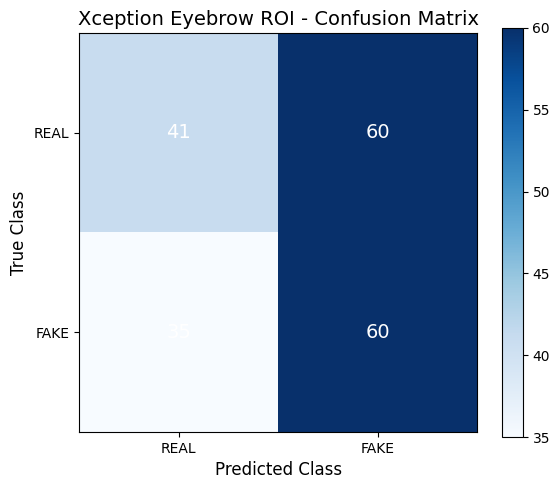

✓ Confusion Matrix kaydedildi.

2/6 - ROC CURVE


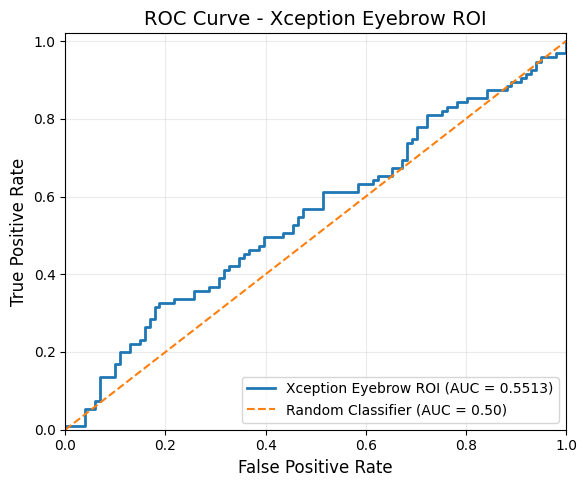

✓ ROC Curve kaydedildi. AUC = 0.5513

3/6 - FROZEN TRAINING CURVES


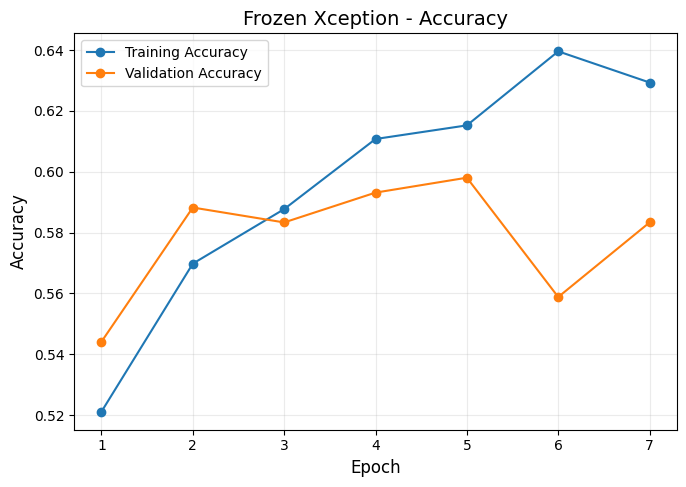

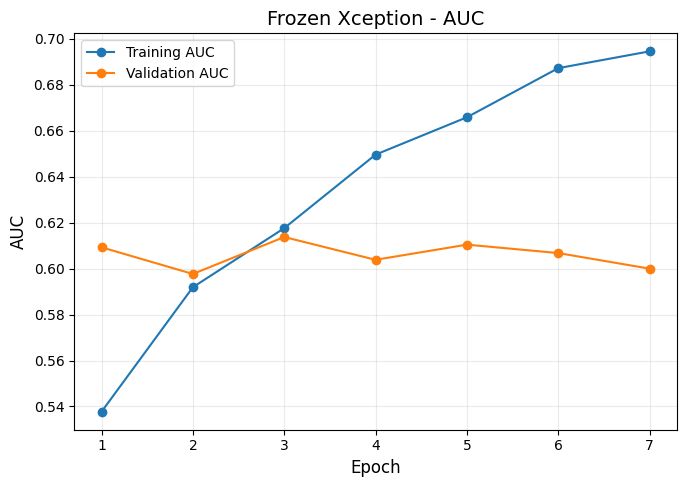

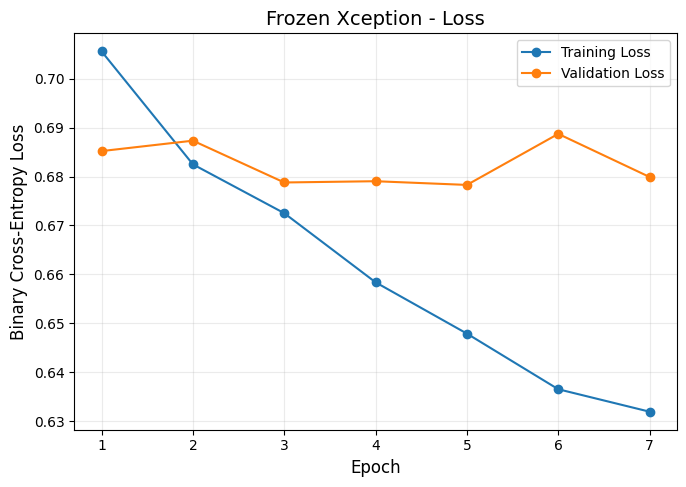

✓ Frozen training grafikleri oluşturuldu.

4/6 - FINE-TUNING CURVES


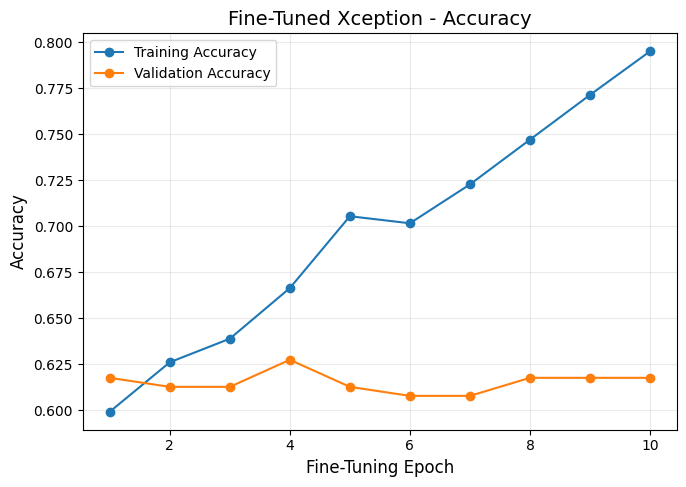

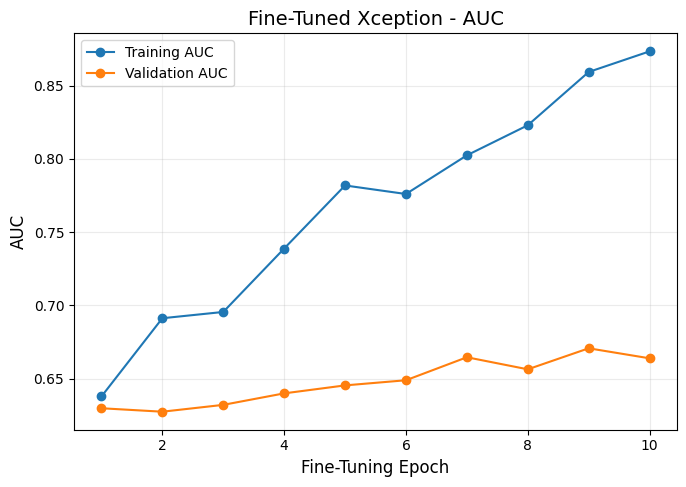

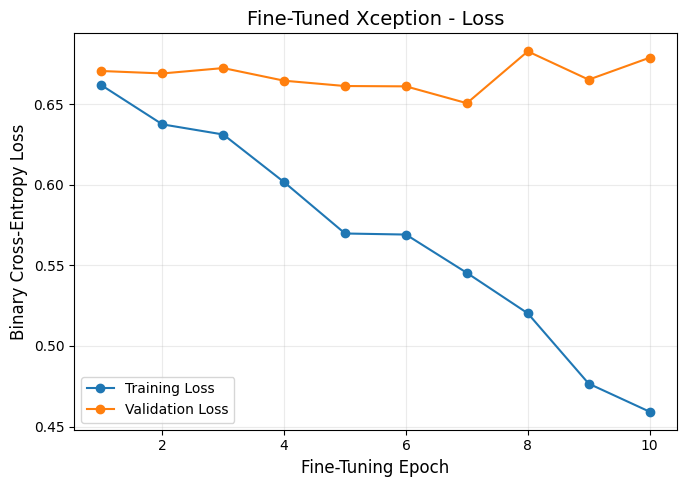

✓ Fine-tuning grafikleri oluşturuldu.

5/6 - FROZEN VS FINE-TUNED


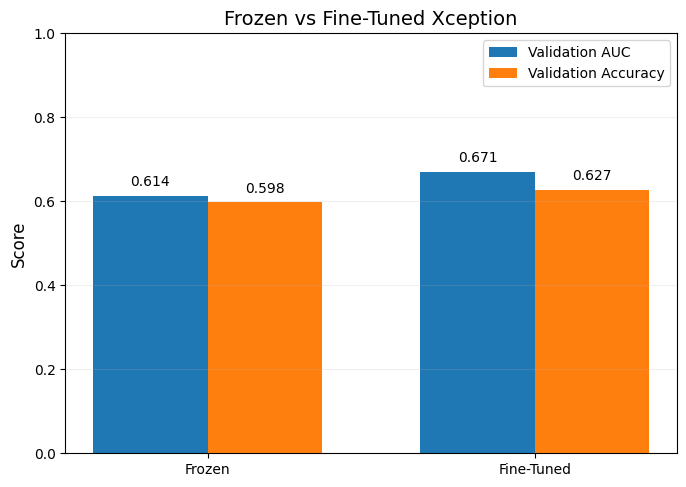

✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu.

6/6 - FINAL TEST METRICS


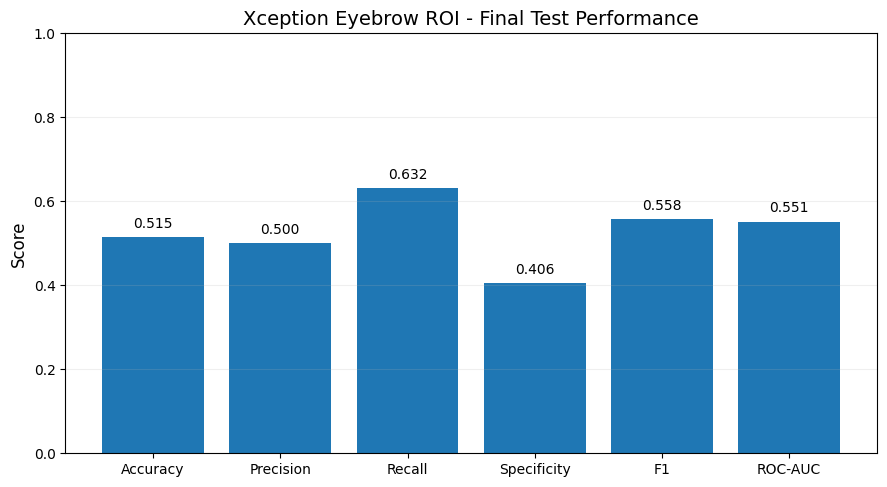

✓ Final test metric grafiği oluşturuldu.

✓ CELL 11 BAŞARIYLA TAMAMLANDI
✓ Toplam PNG grafik sayısı: 10
✓ Grafik çözünürlüğü: 600 DPI
✓ Confusion Matrix oluşturuldu.
✓ ROC Curve oluşturuldu.
✓ Frozen training grafikleri oluşturuldu.
✓ Fine-tuning grafikleri oluşturuldu.
✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu.
✓ Final test metric grafiği oluşturuldu.

Grafiklerin kaydedildiği klasör:
/content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow/figures

✓ Sonraki ve SON aşama: CELL 12


In [11]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# CELL 11 - VISUALIZATION & REPORT FIGURES
# ==========================================================
#
# Bu hücre:
#
# 1) Confusion Matrix
# 2) ROC Curve
# 3) Frozen Training Curves
# 4) Fine-Tuning Training Curves
# 5) Frozen vs Fine-Tuned Validation Comparison
# 6) Final Test Metrics Bar Chart
#
# oluşturur.
#
# Tüm grafikler:
#       PNG
#       600 DPI
#
# olarak Drive'a kaydedilir.
#
# MODEL EĞİTİMİ YAPILMAZ.
# ==========================================================


# ==========================================================
# 1. IMPORTS
# ==========================================================

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    auc
)


print("=" * 75)
print("XCEPTION - REPORT FIGURES")
print("=" * 75)


# ==========================================================
# 2. GEREKLİ DEĞİŞKENLERİ KONTROL ET
# ==========================================================

required_variables = [
    "y_true",
    "y_pred",
    "test_probabilities",
    "RESULTS_DIR"
]


missing_variables = [

    variable_name

    for variable_name in required_variables

    if variable_name not in globals()
]


if len(missing_variables) > 0:

    raise NameError(
        "Eksik değişkenler: "
        + ", ".join(missing_variables)
        + "\nÖnce Cell 9 ve Cell 10'u çalıştır."
    )


# ==========================================================
# 3. FIGURES KLASÖRÜ
# ==========================================================

if "FIGURES_DIR" not in globals():
    FIGURES_DIR = RUN_ROOT / "figures"

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "\nGrafik klasörü:"
)

print(
    FIGURES_DIR
)


print(
    "\n✓ Grafik klasörü hazır."
)


# ==========================================================
# 4. GENEL GRAFİK AYARLARI
# ==========================================================

plt.rcParams.update({

    "font.size": 11,

    "axes.titlesize": 14,

    "axes.labelsize": 12,

    "xtick.labelsize": 10,

    "ytick.labelsize": 10,

    "legend.fontsize": 10,

    "figure.titlesize": 15
})


# ==========================================================
# 5. CONFUSION MATRIX
# ==========================================================

print("\n" + "=" * 75)
print("1/6 - CONFUSION MATRIX")
print("=" * 75)


cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        0,
        1
    ]
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


im = ax.imshow(
    cm,
    cmap="Blues"
)


ax.set_title(
    "Xception Eyebrow ROI - Confusion Matrix"
)


ax.set_xlabel(
    "Predicted Class"
)


ax.set_ylabel(
    "True Class"
)


ax.set_xticks(
    [
        0,
        1
    ]
)


ax.set_yticks(
    [
        0,
        1
    ]
)


ax.set_xticklabels(
    [
        "REAL",
        "FAKE"
    ]
)


ax.set_yticklabels(
    [
        "REAL",
        "FAKE"
    ]
)


# Hücre sayılarını yaz
threshold = (
    cm.max()
    / 2
)


for i in range(
    cm.shape[0]
):

    for j in range(
        cm.shape[1]
    ):

        ax.text(

            j,
            i,

            str(
                cm[i, j]
            ),

            ha="center",
            va="center",

            fontsize=14,

            color=(
                "white"
                if cm[i, j] > threshold
                else "black"
            )
        )


fig.colorbar(
    im,
    ax=ax
)


plt.tight_layout()


CONFUSION_MATRIX_PATH = (
    FIGURES_DIR
    / "01_confusion_matrix.png"
)


plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "✓ Confusion Matrix kaydedildi."
)


# ==========================================================
# 6. ROC CURVE
# ==========================================================

print("\n" + "=" * 75)
print("2/6 - ROC CURVE")
print("=" * 75)


fpr, tpr, roc_thresholds = roc_curve(

    y_true,

    test_probabilities
)


roc_auc_value = auc(
    fpr,
    tpr
)


fig, ax = plt.subplots(
    figsize=(
        6,
        5
    )
)


ax.plot(

    fpr,
    tpr,

    linewidth=2,

    label=(
        f"Xception Eyebrow ROI "
        f"(AUC = {roc_auc_value:.4f})"
    )
)


# Random classifier çizgisi
ax.plot(

    [
        0,
        1
    ],

    [
        0,
        1
    ],

    linestyle="--",

    linewidth=1.5,

    label="Random Classifier (AUC = 0.50)"
)


ax.set_xlim(
    [
        0,
        1
    ]
)


ax.set_ylim(
    [
        0,
        1.02
    ]
)


ax.set_xlabel(
    "False Positive Rate"
)


ax.set_ylabel(
    "True Positive Rate"
)


ax.set_title(
    "ROC Curve - Xception Eyebrow ROI"
)


ax.grid(
    alpha=0.25
)


ax.legend(
    loc="lower right"
)


plt.tight_layout()


ROC_CURVE_PATH = (
    FIGURES_DIR
    / "02_roc_curve.png"
)


plt.savefig(
    ROC_CURVE_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    f"✓ ROC Curve kaydedildi. "
    f"AUC = {roc_auc_value:.4f}"
)


# ==========================================================
# 7. FROZEN TRAINING HISTORY
# ==========================================================

print("\n" + "=" * 75)
print("3/6 - FROZEN TRAINING CURVES")
print("=" * 75)


FROZEN_HISTORY_PATH = (
    RESULTS_DIR
    / "frozen_training_history.csv"
)


if FROZEN_HISTORY_PATH.exists():

    frozen_history = pd.read_csv(
        FROZEN_HISTORY_PATH
    )


    epochs_frozen = np.arange(
        1,
        len(frozen_history) + 1
    )


    # ------------------------------------------------------
    # FROZEN ACCURACY
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "accuracy"
        ],

        marker="o",

        label="Training Accuracy"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_accuracy"
        ],

        marker="o",

        label="Validation Accuracy"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Accuracy"
    )


    ax.set_title(
        "Frozen Xception - Accuracy"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "03_frozen_accuracy.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FROZEN AUC
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "auc"
        ],

        marker="o",

        label="Training AUC"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_auc"
        ],

        marker="o",

        label="Validation AUC"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "AUC"
    )


    ax.set_title(
        "Frozen Xception - AUC"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "04_frozen_auc.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FROZEN LOSS
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "loss"
        ],

        marker="o",

        label="Training Loss"
    )


    ax.plot(

        epochs_frozen,

        frozen_history[
            "val_loss"
        ],

        marker="o",

        label="Validation Loss"
    )


    ax.set_xlabel(
        "Epoch"
    )


    ax.set_ylabel(
        "Binary Cross-Entropy Loss"
    )


    ax.set_title(
        "Frozen Xception - Loss"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "05_frozen_loss.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Frozen training grafikleri oluşturuldu."
    )


else:

    print(
        "⚠ frozen_training_history.csv bulunamadı."
    )


# ==========================================================
# 8. FINE-TUNING HISTORY
# ==========================================================

print("\n" + "=" * 75)
print("4/6 - FINE-TUNING CURVES")
print("=" * 75)


FINETUNE_HISTORY_PATH = (
    RESULTS_DIR
    / "finetune_training_history.csv"
)


if FINETUNE_HISTORY_PATH.exists():

    finetune_history = pd.read_csv(
        FINETUNE_HISTORY_PATH
    )


    epochs_finetune = np.arange(
        1,
        len(finetune_history) + 1
    )


    # ------------------------------------------------------
    # FINE-TUNING ACCURACY
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "accuracy"
        ],

        marker="o",

        label="Training Accuracy"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_accuracy"
        ],

        marker="o",

        label="Validation Accuracy"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "Accuracy"
    )


    ax.set_title(
        "Fine-Tuned Xception - Accuracy"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "06_finetune_accuracy.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FINE-TUNING AUC
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "auc"
        ],

        marker="o",

        label="Training AUC"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_auc"
        ],

        marker="o",

        label="Validation AUC"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "AUC"
    )


    ax.set_title(
        "Fine-Tuned Xception - AUC"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "07_finetune_auc.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    # ------------------------------------------------------
    # FINE-TUNING LOSS
    # ------------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "loss"
        ],

        marker="o",

        label="Training Loss"
    )


    ax.plot(

        epochs_finetune,

        finetune_history[
            "val_loss"
        ],

        marker="o",

        label="Validation Loss"
    )


    ax.set_xlabel(
        "Fine-Tuning Epoch"
    )


    ax.set_ylabel(
        "Binary Cross-Entropy Loss"
    )


    ax.set_title(
        "Fine-Tuned Xception - Loss"
    )


    ax.grid(
        alpha=0.25
    )


    ax.legend()


    plt.tight_layout()


    path = (
        FIGURES_DIR
        / "08_finetune_loss.png"
    )


    plt.savefig(
        path,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Fine-tuning grafikleri oluşturuldu."
    )


else:

    print(
        "⚠ finetune_training_history.csv bulunamadı."
    )


# ==========================================================
# 9. FROZEN VS FINE-TUNED VALIDATION PERFORMANCE
# ==========================================================

print("\n" + "=" * 75)
print("5/6 - FROZEN VS FINE-TUNED")
print("=" * 75)


FROZEN_SUMMARY_PATH = (
    RESULTS_DIR
    / "frozen_training_summary.json"
)


FINETUNE_SUMMARY_PATH = (
    RESULTS_DIR
    / "finetune_training_summary.json"
)


if (
    FROZEN_SUMMARY_PATH.exists()
    and
    FINETUNE_SUMMARY_PATH.exists()
):


    with open(
        FROZEN_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        frozen_summary = json.load(
            file
        )


    with open(
        FINETUNE_SUMMARY_PATH,
        "r",
        encoding="utf-8"
    ) as file:

        finetune_summary = json.load(
            file
        )


    frozen_auc = float(
        frozen_summary[
            "best_validation_auc"
        ]
    )


    finetune_auc = float(
        finetune_summary[
            "best_validation_auc"
        ]
    )


    frozen_acc = float(
        frozen_summary[
            "best_validation_accuracy"
        ]
    )


    finetune_acc = float(
        finetune_summary[
            "best_validation_accuracy"
        ]
    )


    stages = [
        "Frozen",
        "Fine-Tuned"
    ]


    auc_values = [
        frozen_auc,
        finetune_auc
    ]


    accuracy_values = [
        frozen_acc,
        finetune_acc
    ]


    x = np.arange(
        len(stages)
    )


    width = 0.35


    fig, ax = plt.subplots(
        figsize=(
            7,
            5
        )
    )


    bars_auc = ax.bar(

        x - width / 2,

        auc_values,

        width,

        label="Validation AUC"
    )


    bars_acc = ax.bar(

        x + width / 2,

        accuracy_values,

        width,

        label="Validation Accuracy"
    )


    ax.set_ylabel(
        "Score"
    )


    ax.set_ylim(
        0,
        1
    )


    ax.set_xticks(
        x
    )


    ax.set_xticklabels(
        stages
    )


    ax.set_title(
        "Frozen vs Fine-Tuned Xception"
    )


    ax.legend()


    ax.grid(
        axis="y",
        alpha=0.20
    )


    # Sayıları barların üzerine yaz
    for bars in [
        bars_auc,
        bars_acc
    ]:

        for bar in bars:

            height = bar.get_height()

            ax.text(

                bar.get_x()
                +
                bar.get_width() / 2,

                height + 0.015,

                f"{height:.3f}",

                ha="center",
                va="bottom",

                fontsize=10
            )


    plt.tight_layout()


    COMPARISON_PATH = (
        FIGURES_DIR
        / "09_frozen_vs_finetuned.png"
    )


    plt.savefig(
        COMPARISON_PATH,
        dpi=600,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()


    print(
        "✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu."
    )


else:

    print(
        "⚠ Training summary dosyaları bulunamadı."
    )


# ==========================================================
# 10. FINAL TEST METRICS BAR CHART
# ==========================================================

print("\n" + "=" * 75)
print("6/6 - FINAL TEST METRICS")
print("=" * 75)


# Cell 10'dan gelen metrikleri kullanıyoruz.

metric_names = [
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "ROC-AUC"
]


metric_values = [
    float(accuracy),
    float(precision),
    float(recall),
    float(specificity),
    float(f1),
    float(roc_auc)
]


fig, ax = plt.subplots(
    figsize=(
        9,
        5
    )
)


bars = ax.bar(
    metric_names,
    metric_values
)


ax.set_ylim(
    0,
    1
)


ax.set_ylabel(
    "Score"
)


ax.set_title(
    "Xception Eyebrow ROI - Final Test Performance"
)


ax.grid(
    axis="y",
    alpha=0.20
)


# Değerleri barların üzerine yaz

for bar, value in zip(
    bars,
    metric_values
):

    ax.text(

        bar.get_x()
        +
        bar.get_width() / 2,

        value + 0.015,

        f"{value:.3f}",

        ha="center",
        va="bottom",

        fontsize=10
    )


plt.tight_layout()


FINAL_METRICS_FIGURE_PATH = (
    FIGURES_DIR
    / "10_final_test_metrics.png"
)


plt.savefig(
    FINAL_METRICS_FIGURE_PATH,
    dpi=600,
    bbox_inches="tight"
)


plt.show()

plt.close()


print(
    "✓ Final test metric grafiği oluşturuldu."
)


# ==========================================================
# 11. FIGURE MANIFEST
# ==========================================================
#
# Hangi grafiklerin oluşturulduğunu kaydediyoruz.


figure_files = sorted(

    [
        file.name

        for file in FIGURES_DIR.glob(
            "*.png"
        )
    ]
)


figure_manifest = {

    "region":
        "eyebrow",

    "model":
        "Xception",

    "dpi":
        600,

    "figure_count":
        len(
            figure_files
        ),

    "figures":
        figure_files
}


FIGURE_MANIFEST_PATH = (
    RESULTS_DIR
    / "figure_manifest.json"
)


with open(
    FIGURE_MANIFEST_PATH,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        figure_manifest,
        file,
        ensure_ascii=False,
        indent=4
    )


# ==========================================================
# 12. SONUÇ
# ==========================================================

print("\n" + "=" * 75)

print(
    "✓ CELL 11 BAŞARIYLA TAMAMLANDI"
)

print(
    f"✓ Toplam PNG grafik sayısı: "
    f"{len(figure_files)}"
)

print(
    "✓ Grafik çözünürlüğü: 600 DPI"
)

print(
    "✓ Confusion Matrix oluşturuldu."
)

print(
    "✓ ROC Curve oluşturuldu."
)

print(
    "✓ Frozen training grafikleri oluşturuldu."
)

print(
    "✓ Fine-tuning grafikleri oluşturuldu."
)

print(
    "✓ Frozen vs Fine-Tuned karşılaştırması oluşturuldu."
)

print(
    "✓ Final test metric grafiği oluşturuldu."
)

print(
    "\nGrafiklerin kaydedildiği klasör:"
)

print(
    FIGURES_DIR
)

print(
    "\n✓ Sonraki ve SON aşama: CELL 12"
)

print("=" * 75)

In [12]:
# ==========================================================
# EYEBROW DEEPFAKE DETECTION - XCEPTION EXPERIMENT
# CELL 12 - FINAL ARTIFACTS, RUN SUMMARY & OUTPUT MANIFEST
# ==========================================================
#
# BU SON HÜCREDİR.
#
# Sonuç yapısı:
#
# <RUN_ROOT>/
# ├── checkpoints/
# ├── logs/
# ├── metrics/
# ├── predictions/
# ├── figures/
# ├── artifacts/
# ├── config_resolved.yaml
# ├── requirements_lock.txt
# ├── environment.json
# ├── run_summary.json
# └── output_manifest.csv
#
# Bu hücre modeli yeniden eğitmez.
# ==========================================================

import json
import os
import sys
import shutil
import hashlib
import platform
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd

print("=" * 80)
print("XCEPTION EYEBROW - FINAL EXPORT")
print("=" * 80)

# ----------------------------------------------------------
# 1. SEÇİLEN NİHAİ MODELİ ARTIFACTS ALTINA KOPYALA
# ----------------------------------------------------------
if "SELECTED_MODEL_PATH" not in globals():
    raise NameError(
        "SELECTED_MODEL_PATH bulunamadı. Önce Cell 9'u çalıştır."
    )

SELECTED_MODEL_PATH = Path(SELECTED_MODEL_PATH)
if not SELECTED_MODEL_PATH.exists():
    raise FileNotFoundError(f"Seçilen model bulunamadı: {SELECTED_MODEL_PATH}")

FINAL_MODEL_PATH = ARTIFACTS_DIR / "Xception_Eyebrow_Final.keras"
shutil.copy2(SELECTED_MODEL_PATH, FINAL_MODEL_PATH)
print("✓ Final model artifacts klasörüne kopyalandı.")

# ----------------------------------------------------------
# 2. MODEL SUMMARY TXT
# ----------------------------------------------------------
MODEL_SUMMARY_PATH = ARTIFACTS_DIR / "model_summary.txt"

try:
    summary_lines = []
    selected_model.summary(print_fn=lambda x: summary_lines.append(x))
    MODEL_SUMMARY_PATH.write_text("\n".join(summary_lines), encoding="utf-8")
except Exception as exc:
    MODEL_SUMMARY_PATH.write_text(
        f"Model summary üretilemedi: {type(exc).__name__}: {exc}",
        encoding="utf-8"
    )

# ----------------------------------------------------------
# 3. CONFIG_RESOLVED.YAML
# ----------------------------------------------------------
CONFIG_PATH = RUN_ROOT / "config_resolved.yaml"

config_text = f"""experiment:
  run_id: {RUN_ID}
  task: eyebrow_roi_deepfake_detection
  seed: {SEED}
  class_mapping:
    real: 0
    fake: 1

data:
  source_frame_root: \"{SOURCE_FRAME_ROOT}\"
  eyebrow_roi_root: \"{EYEBROW_ROI_ROOT}\"
  train_total: {TRAIN_TOTAL}
  val_total: {VAL_TOTAL}
  test_total: {TEST_TOTAL}
  total_roi: {TOTAL_ROI}

model:
  architecture: Xception
  pretrained_weights: ImageNet
  include_top: false
  input_height: {IMG_HEIGHT}
  input_width: {IMG_WIDTH}
  batch_size: {BATCH_SIZE}
  initial_learning_rate: {INITIAL_LEARNING_RATE if 'INITIAL_LEARNING_RATE' in globals() else 'null'}
  finetune_learning_rate: {FINE_TUNE_LEARNING_RATE if 'FINE_TUNE_LEARNING_RATE' in globals() else 'null'}
  unfreeze_last_n: {UNFREEZE_LAST_N if 'UNFREEZE_LAST_N' in globals() else 'null'}

augmentation:
  horizontal_flip: {str(ENABLE_HORIZONTAL_FLIP).lower() if 'ENABLE_HORIZONTAL_FLIP' in globals() else 'false'}
  rotation_factor: 0.015
  zoom_factor: 0.03
  contrast_factor: 0.03

output:
  run_root: \"{RUN_ROOT}\"
"""
CONFIG_PATH.write_text(config_text, encoding="utf-8")
print("✓ config_resolved.yaml kaydedildi.")

# ----------------------------------------------------------
# 4. REQUIREMENTS LOCK
# ----------------------------------------------------------
REQUIREMENTS_PATH = RUN_ROOT / "requirements_lock.txt"

try:
    freeze_result = subprocess.run(
        [sys.executable, "-m", "pip", "freeze"],
        capture_output=True,
        text=True,
        check=False
    )
    REQUIREMENTS_PATH.write_text(freeze_result.stdout, encoding="utf-8")
except Exception as exc:
    REQUIREMENTS_PATH.write_text(
        f"pip freeze alınamadı: {type(exc).__name__}: {exc}",
        encoding="utf-8"
    )

print("✓ requirements_lock.txt kaydedildi.")

# ----------------------------------------------------------
# 5. ENVIRONMENT.JSON
# ----------------------------------------------------------
ENVIRONMENT_PATH = RUN_ROOT / "environment.json"

try:
    gpu_names = [
        device.name
        for device in tf.config.list_physical_devices("GPU")
    ]
except Exception:
    gpu_names = []

environment = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "tensorflow_version": tf.__version__,
    "keras_version": getattr(keras, "__version__", None),
    "gpu_devices": gpu_names,
    "seed": int(SEED),
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
}

ENVIRONMENT_PATH.write_text(
    json.dumps(environment, ensure_ascii=False, indent=2),
    encoding="utf-8"
)
print("✓ environment.json kaydedildi.")

# ----------------------------------------------------------
# 6. RUN SUMMARY.JSON
# ----------------------------------------------------------
RUN_SUMMARY_PATH = RUN_ROOT / "run_summary.json"

# Cell 10'da final_metrics sözlüğü üretilmiş olmalı.
if "final_metrics" not in globals():
    final_metrics = {}

run_summary = {
    "run_id": RUN_ID,
    "task": "eyebrow_roi_deepfake_detection",
    "region": "eyebrow",
    "model": "Xception",
    "pretrained_weights": "ImageNet",
    "training_strategy": "imagenet_xception_transfer_learning_then_fine_tuning",
    "data_io_strategy": "copy_drive_dataset_to_colab_local_cache_before_training",
    "class_mapping": {"real": 0, "fake": 1},
    "source_frame_root": str(SOURCE_FRAME_ROOT),
    "eyebrow_roi_drive_root": str(EYEBROW_ROI_DRIVE_ROOT),
    "eyebrow_roi_training_cache": str(EYEBROW_ROI_ROOT),
    "results_root": str(RUN_ROOT),
    "dataset": {
        "train_total": int(TRAIN_TOTAL),
        "val_total": int(VAL_TOTAL),
        "test_total": int(TEST_TOTAL),
        "total_roi": int(TOTAL_ROI),
        "fake_train": int(dataset_counts["fake_train"]),
        "real_train": int(dataset_counts["real_train"]),
        "fake_val": int(dataset_counts["fake_val"]),
        "real_val": int(dataset_counts["real_val"]),
        "fake_test": int(dataset_counts["fake_test"]),
        "real_test": int(dataset_counts["real_test"]),
    },
    "model_selection": {
        "selected_model_path": str(SELECTED_MODEL_PATH),
        "final_model_path": str(FINAL_MODEL_PATH),
        "selection_metric": "validation_auc",
        "frozen_best_val_auc": float(frozen_best_val_auc) if "frozen_best_val_auc" in globals() else None,
        "finetuned_best_val_auc": float(finetuned_best_val_auc) if "finetuned_best_val_auc" in globals() else None,
    },
    "test_metrics": final_metrics,
    "started_at_utc": RUN_STARTED_AT_UTC,
    "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "duration_seconds": round(float(time.time() - RUN_START_TS), 3),
}

RUN_SUMMARY_PATH.write_text(
    json.dumps(run_summary, ensure_ascii=False, indent=2, default=str),
    encoding="utf-8"
)
print("✓ run_summary.json kaydedildi.")

# ----------------------------------------------------------
# 7. OUTPUT MANIFEST.CSV
# ----------------------------------------------------------
def sha256_file(path, chunk_size=1024 * 1024):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while True:
            chunk = f.read(chunk_size)
            if not chunk:
                break
            h.update(chunk)
    return h.hexdigest()

manifest_rows = []

for path in sorted(RUN_ROOT.rglob("*")):
    if not path.is_file():
        continue

    # Manifest kendisini hesaba katmadan önce oluşturuyoruz.
    if path.name == "output_manifest.csv":
        continue

    manifest_rows.append({
        "relative_path": str(path.relative_to(RUN_ROOT)),
        "file_name": path.name,
        "size_bytes": int(path.stat().st_size),
        "sha256": sha256_file(path),
    })

OUTPUT_MANIFEST_PATH = RUN_ROOT / "output_manifest.csv"
pd.DataFrame(manifest_rows).to_csv(
    OUTPUT_MANIFEST_PATH,
    index=False,
    encoding="utf-8"
)
print("✓ output_manifest.csv kaydedildi.")

# ----------------------------------------------------------
# 8. FINAL STRUCTURE CHECK
# ----------------------------------------------------------
required_directories = [
    CHECKPOINTS_DIR,
    LOGS_DIR,
    METRICS_DIR,
    PREDICTIONS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
]

required_root_files = [
    CONFIG_PATH,
    REQUIREMENTS_PATH,
    ENVIRONMENT_PATH,
    RUN_SUMMARY_PATH,
    OUTPUT_MANIFEST_PATH,
]

print("\n" + "=" * 80)
print("FINAL OUTPUT CHECK")
print("=" * 80)

for folder in required_directories:
    print(f"DIR  ✓ {folder.relative_to(RUN_ROOT)}/")

for file_path in required_root_files:
    print(f"FILE ✓ {file_path.relative_to(RUN_ROOT)}")

print("\n" + "=" * 80)
print("✓ XCEPTION EYEBROW DENEYİ TAMAMLANDI")
print(f"✓ Tüm çıktılar: {RUN_ROOT}")
print("✓ Kaş ROI girdi klasöründe hiçbir dosya değiştirilmedi.")
print("=" * 80)


XCEPTION EYEBROW - FINAL EXPORT
✓ Final model artifacts klasörüne kopyalandı.
✓ config_resolved.yaml kaydedildi.
✓ requirements_lock.txt kaydedildi.
✓ environment.json kaydedildi.
✓ run_summary.json kaydedildi.
✓ output_manifest.csv kaydedildi.

FINAL OUTPUT CHECK
DIR  ✓ checkpoints/
DIR  ✓ logs/
DIR  ✓ metrics/
DIR  ✓ predictions/
DIR  ✓ figures/
DIR  ✓ artifacts/
FILE ✓ config_resolved.yaml
FILE ✓ requirements_lock.txt
FILE ✓ environment.json
FILE ✓ run_summary.json
FILE ✓ output_manifest.csv

✓ XCEPTION EYEBROW DENEYİ TAMAMLANDI
✓ Tüm çıktılar: /content/drive/MyDrive/AISC DeepFake Çalışmaları/Deneyler/Nazlıcan/Deney 1/Sonuçlar/20260807_123945_xception_eyebrow
✓ Kaş ROI girdi klasöründe hiçbir dosya değiştirilmedi.
